# HQSS: Hybrid Quantum Synthetic Supplementation for OD Time Series Prediction

**Experiment:** Generate synthetic OD growth curves from 4 models (qGAN, qVAE, cGAN, cVAE),
augment real training data with synthetic curves, train LSTM predictors, evaluate on held-out real data.
Repeat on IBM quantum hardware for qGAN and qVAE.

**Design:**
- 4 models × 3 set sizes (50, 150, 250 synthetic OD curves) × 3 seeds = 36 LSTM experiments per stage
- Baseline: LSTM on real data only
- IBM stage: qGAN + qVAE on real hardware, same matrix
- Metrics: MSE, MAPE on held-out real log-return test set

**Preprocessing:** OD → log-returns (dithered) → z-score normalize → Lambert-W Gaussianize

In [1]:
#%pip install numpy pandas matplotlib scipy torch pennylane scikit-learn
#%pip install statsmodels
#%pip install tqdm

In [2]:
# ── 0. CONFIGURATION ─────────────────────────────────────────────────────────
from pathlib import Path

# Paths (all local — notebook is fully self-contained)
ROOT          = Path('.')
DATA_PATH     = ROOT / 'data.csv'
CKPT_DIR      = ROOT / 'checkpoints'
FIGURES_DIR   = ROOT / 'figures'
QGAN_CKPT     = CKPT_DIR / 'models' / 'qgan.pt'
QVAE_CKPT     = CKPT_DIR / 'models' / 'qvae.pt'
CGAN_CKPT     = CKPT_DIR / 'models' / 'cgan.pt'
CVAE_CKPT     = CKPT_DIR / 'models' / 'cvae.pt'

# ── Force-retrain flags (set True to retrain from scratch) ────────────────────
FORCE_TRAIN_QGAN   = False 
FORCE_TRAIN_QVAE   = False
FORCE_TRAIN_CGAN   = False
FORCE_TRAIN_CVAE   = False
FORCE_GENERATE     = False
FORCE_LSTM         = False

# ── Experiment parameters ─────────────────────────────────────────────────────
SYNTH_SIZES  = [50, 150, 250]   # synthetic OD curves per set
N_SEEDS      = 3
GEN_SEEDS    = [42, 137, 271]

# ── qGAN architecture ─────────────────────────────────────────────────────────
NUM_QUBITS    = 5
NUM_LAYERS    = 4
WINDOW_GAN    = 2 * NUM_QUBITS  # 10

# ── Phase 1 prototyping flags ─────────────────────────────────────────────────
PHASE1_REDUCED     = True
QGAN_EPOCHS_PHASE1 = 10           # reduced from 500 for pipeline verification
QVAE_EPOCHS_PHASE1 = 10           # reduced from 50 for pipeline verification
CGAN_EPOCHS_PHASE1 = 10           # reduced from 500 for pipeline verification
CVAE_EPOCHS_PHASE1 = 10           # reduced from 200 for pipeline verification

# ── qGAN training (HPO-optimal hyperparameters from qGAN project) ─────────────
QGAN_EPOCHS     = 500           # ~30-90 min with lightning.qubit
QGAN_LR_GEN     = 7e-5          # Adam β=(0.0, 0.9)
QGAN_LR_CRIT    = 1.8e-5
QGAN_N_CRITIC   = 9
QGAN_LAMBDA_GP  = 2.16
QGAN_LAMBDA_ACF = 0.062         # ACF penalty weight

# ── qVAE / cVAE architecture ──────────────────────────────────────────────────
WINDOW_VAE    = 32
LATENT_DIM    = 12
STRIDE_VAE    = 1

# ── qVAE training ─────────────────────────────────────────────────────────────
QVAE_EPOCHS   = 50              # diminishing returns after ~60 epochs
QVAE_LR       = 1e-3

# ── cGAN architecture ─────────────────────────────────────────────────────────
NOISE_DIM_CGAN = NUM_QUBITS
HIDDEN_CGAN    = 64

# ── cVAE architecture ─────────────────────────────────────────────────────────
HIDDEN_CVAE   = 128

# ── Classical model training ──────────────────────────────────────────────────
CGAN_EPOCHS   = 500
CVAE_EPOCHS   = 200
CGAN_LR       = 1e-4
CVAE_LR       = 1e-3
BATCH_SIZE    = 32
N_CRITIC      = 5
LAMBDA_GP     = 10.0

# ── Preprocessing ─────────────────────────────────────────────────────────────
DITHER        = 0.005
MAX_PAR_LIGHT = 12.5

# ── LSTM ──────────────────────────────────────────────────────────────────────
LOOKBACK      = 20
LSTM_HIDDEN   = 64
LSTM_LAYERS   = 2
LSTM_DROPOUT  = 0.2
LSTM_EPOCHS   = 50
LSTM_LR       = 1e-3
TRAIN_FRAC    = 0.80

print('Configuration loaded.')
print(f'Synthetic sets: {len(SYNTH_SIZES)} sizes × {N_SEEDS} seeds = {len(SYNTH_SIZES)*N_SEEDS} per model')
print(f'Total LSTM runs: 4 models × {len(SYNTH_SIZES)*N_SEEDS} sets + 1 baseline = {4*len(SYNTH_SIZES)*N_SEEDS + 1}')


Configuration loaded.
Synthetic sets: 3 sizes × 3 seeds = 9 per model
Total LSTM runs: 4 models × 9 sets + 1 baseline = 37


In [3]:
# ── 1. IMPORTS ────────────────────────────────────────────────────────────────
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import wasserstein_distance
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR

import pennylane as qml

# qzeta (installed package — no external path required)
from qzeta.models import FullQuantumVAE
from qzeta.config import Config, TrainingConfig
from qzeta.training import Trainer

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available()
                      else 'cpu')
print(f'PyTorch device: {DEVICE}')
print(f'PennyLane version: {qml.__version__}')

THEME_PRIMARY = 'darkgreen'
THEME_SYNTH   = '#E05C00'
THEME_CLS     = '#0066CC'
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})


PyTorch device: mps
PennyLane version: 0.44.1


In [4]:
# ── 2. DIRECTORY SETUP ────────────────────────────────────────────────────────
for sub in ['models', 'synthetic/qgan', 'synthetic/qvae', 'synthetic/cgan', 'synthetic/cvae',
            'lstm_results', 'ibm/synthetic', 'ibm/lstm_results']:
    (CKPT_DIR / sub).mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
print('Checkpoint and figure directories ready.')

Checkpoint and figure directories ready.


## Biological Framing: Specific Growth Rate

The core quantity modelled throughout this notebook is the **specific growth rate**:

$$\mu = \frac{d(\ln \text{OD})}{dt}$$

This is the standard microbiological definition of specific growth rate — the instantaneous
fractional rate of increase in biomass (approximated here by optical density). Computing
the first difference of log(OD) yields a discrete approximation of µ at each measurement
interval.


In [5]:
# ── 3. DATA LOADING & PREPROCESSING ──────────────────────────────────────────

# ── 3.1 Load raw data ────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
raw_od    = pd.to_numeric(df['OD'], errors='coerce').ffill().dropna().values.astype(np.float64)
raw_light = df['PAR_LIGHT'].values[:len(raw_od)].astype(np.float64)

print(f'OD series: {len(raw_od)} points, range [{raw_od.min():.3f}, {raw_od.max():.3f}]')
print(f'PAR_LIGHT: range [{raw_light.min():.1f}, {raw_light.max():.1f}]')

# ── 3.2 Specific growth rate with dithering ──────────────────────────────────
rng_pre = np.random.default_rng(42)
od_dithered = raw_od + rng_pre.uniform(-DITHER, DITHER, size=len(raw_od))
od_dithered = np.maximum(od_dithered, 1e-10)
growth_rate = np.diff(np.log(od_dithered)).astype(np.float32)

print(f'Growth rate: {len(growth_rate)} points, mean={growth_rate.mean():.6f}, std={growth_rate.std():.6f}')

# ── 3.3 Z-score normalization ─────────────────────────────────────────────────
MU    = float(growth_rate.mean())
SIGMA = float(growth_rate.std())
norm_growth_rate = ((growth_rate - MU) / SIGMA).astype(np.float32)

print(f'Z-score: mu={MU:.6f}, sigma={SIGMA:.6f}')

# ── 3.4 Scale to [-1, 1]  (qGAN training space) ──────────────────────────────
GR_MIN = float(norm_growth_rate.min())
GR_MAX = float(norm_growth_rate.max())
scaled_data = (-1.0 + 2.0 * (norm_growth_rate - GR_MIN) / (GR_MAX - GR_MIN)).astype(np.float32)

# ── 3.6 PAR_LIGHT normalization ───────────────────────────────────────────────
par_norm   = (raw_light / MAX_PAR_LIGHT).astype(np.float32)   # [0, 1]
par_scaled = (-1.0 + 2.0 * par_norm).astype(np.float32)       # [-1, 1]
# Trim to log-delta length (N-1)
par_norm_trim   = par_norm[:-1]
par_scaled_trim = par_scaled[:-1]

print(f'Scaled [-1,1]: mean={scaled_data.mean():.4f}, std={scaled_data.std():.4f}')
print(f'Z-score range: [{GR_MIN:.4f}, {GR_MAX:.4f}]')
print(f'PAR_LIGHT trimmed length: {len(par_norm_trim)}')

OD series: 778 points, range [0.470, 3.800]
PAR_LIGHT: range [0.0, 12.5]
Growth rate: 777 points, mean=0.002449, std=0.021745
Z-score: mu=0.002449, sigma=0.021745
Scaled [-1,1]: mean=-0.0458, std=0.2679
Z-score range: [-3.5614, 3.9031]
PAR_LIGHT trimmed length: 777


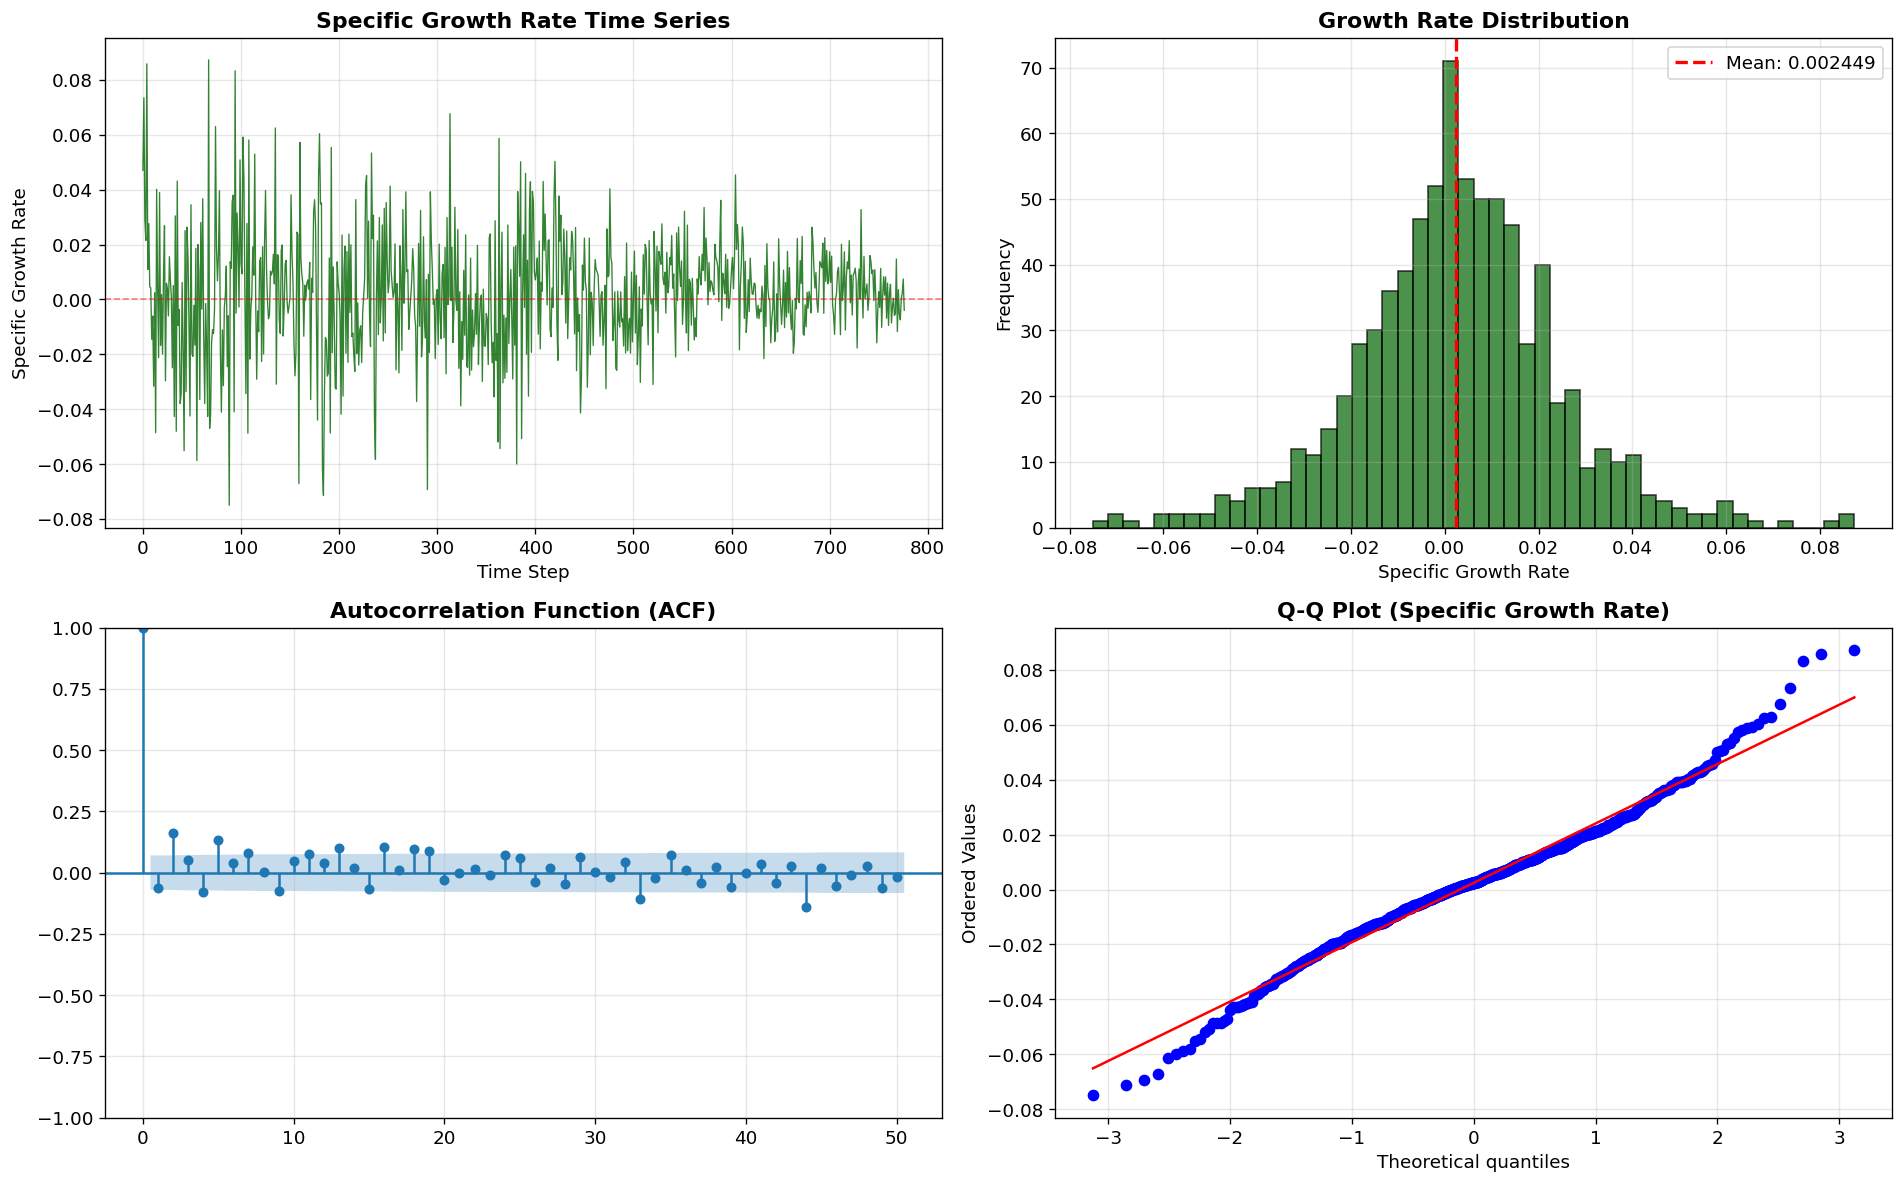

Saved: preprocessing_diagnostic.png


In [6]:
# ── 3.7 Preprocessing diagnostic (4-panel) ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(growth_rate, linewidth=0.8, color=THEME_PRIMARY, alpha=0.8)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 0].set_xlabel('Time Step'); axes[0, 0].set_ylabel('Specific Growth Rate')
axes[0, 0].set_title('Specific Growth Rate Time Series', fontweight='bold')

axes[0, 1].hist(growth_rate, bins=50, color=THEME_PRIMARY, alpha=0.7, edgecolor='black')
axes[0, 1].axvline(growth_rate.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {growth_rate.mean():.6f}')
axes[0, 1].set_xlabel('Specific Growth Rate'); axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Growth Rate Distribution', fontweight='bold')
axes[0, 1].legend()

plot_acf(growth_rate, lags=50, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('Autocorrelation Function (ACF)', fontweight='bold')

stats.probplot(growth_rate, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Specific Growth Rate)', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'preprocessing_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: preprocessing_diagnostic.png')

In [7]:
# ── 4. qGAN GENERATOR CIRCUIT ───────────────────────────────────────────────
# Recreates the IQP + StronglyEntangling circuit from qGAN/qgan_pennylane.ipynb
# Circuit signature must match best_checkpoint_par_conditioned.pt exactly.

# Auto-detect backend: lightning.qubit (adjoint) ~150× faster than default.qubit
try:
    _dev_qgan = qml.device('lightning.qubit', wires=NUM_QUBITS)
    _qgan_diff = 'adjoint'
    print('qGAN backend: lightning.qubit + adjoint  (~150× vs default.qubit+parameter-shift)')
except Exception:
    _dev_qgan = qml.device('default.qubit', wires=NUM_QUBITS)
    _qgan_diff = 'parameter-shift'
    print('qGAN backend: default.qubit + parameter-shift  (pip install pennylane-lightning for speedup)')

def _qgan_circuit_fn(noise_params, par_light_params, params_pqc):
    idx = 0
    # Hadamard initialisation
    for q in range(NUM_QUBITS):
        qml.Hadamard(wires=q)
    # IQP encoding (trainable RZ)
    for q in range(NUM_QUBITS):
        qml.RZ(params_pqc[idx], wires=q)
        idx += 1
    # Noise encoding (RZ, fixed per call)
    for q in range(NUM_QUBITS):
        qml.RZ(noise_params[q], wires=q)
    # PAR_LIGHT conditioning (RY)
    for q in range(NUM_QUBITS):
        qml.RY(par_light_params[q] * np.pi, wires=q)
    # Strongly-entangling layers
    for layer in range(NUM_LAYERS):
        for q in range(NUM_QUBITS):
            qml.Rot(params_pqc[idx], params_pqc[idx + 1], params_pqc[idx + 2], wires=q)
            idx += 3
        r = (layer % (NUM_QUBITS - 1)) + 1
        for q in range(NUM_QUBITS):
            qml.CNOT(wires=[q, (q + r) % NUM_QUBITS])
    # Final measurement-prep rotations
    for q in range(NUM_QUBITS):
        qml.RX(params_pqc[idx], wires=q); idx += 1
        qml.RY(params_pqc[idx], wires=q); idx += 1
    # PauliX + PauliZ per qubit -> WINDOW_GAN = 10 outputs
    return tuple(qml.expval(qml.PauliX(q)) for q in range(NUM_QUBITS)) + \
           tuple(qml.expval(qml.PauliZ(q)) for q in range(NUM_QUBITS))

_qgan_circuit_sim = qml.QNode(_qgan_circuit_fn, _dev_qgan,
                               interface='torch', diff_method=_qgan_diff)

# Expected param count (must match checkpoint)
_n_params_qgan = NUM_QUBITS + NUM_LAYERS * NUM_QUBITS * 3 + NUM_QUBITS * 2
print(f'qGAN generator params: {_n_params_qgan}')
print(f'  IQP: {NUM_QUBITS}  SEL: {NUM_LAYERS}×{NUM_QUBITS}×3={NUM_LAYERS*NUM_QUBITS*3}  Final: {NUM_QUBITS*2}')
print(f'Output dim (WINDOW_GAN): {WINDOW_GAN}')


qGAN backend: lightning.qubit + adjoint  (~150× vs default.qubit+parameter-shift)
qGAN generator params: 75
  IQP: 5  SEL: 4×5×3=60  Final: 10
Output dim (WINDOW_GAN): 10


In [8]:
# ── 4b. NO-PAR qGAN CIRCUIT (PAR_LIGHT ABLATION) ─────────────────────────────
# Identical to _qgan_circuit_fn but with the PAR_LIGHT RY block omitted.
# Signature: (noise_params, params_pqc) — no par_light_params argument.
# The trained param count remains 75 (PAR was a runtime input, not a trained param).

def _qgan_circuit_fn_no_par(noise_params, params_pqc):
    """qGAN circuit without PAR_LIGHT conditioning (ablation)."""
    idx = 0
    # Hadamard initialisation
    for q in range(NUM_QUBITS):
        qml.Hadamard(wires=q)
    # IQP encoding (trainable RZ)
    for q in range(NUM_QUBITS):
        qml.RZ(params_pqc[idx], wires=q)
        idx += 1
    # Noise encoding (RZ, fixed per call)
    for q in range(NUM_QUBITS):
        qml.RZ(noise_params[q], wires=q)
    # PAR_LIGHT RY block intentionally omitted (ablation)
    # Strongly-entangling layers
    for layer in range(NUM_LAYERS):
        for q in range(NUM_QUBITS):
            qml.Rot(params_pqc[idx], params_pqc[idx + 1], params_pqc[idx + 2], wires=q)
            idx += 3
        r = (layer % (NUM_QUBITS - 1)) + 1
        for q in range(NUM_QUBITS):
            qml.CNOT(wires=[q, (q + r) % NUM_QUBITS])
    # Final measurement-prep rotations
    for q in range(NUM_QUBITS):
        qml.RX(params_pqc[idx], wires=q); idx += 1
        qml.RY(params_pqc[idx], wires=q); idx += 1
    return (tuple(qml.expval(qml.PauliX(q)) for q in range(NUM_QUBITS)) +
            tuple(qml.expval(qml.PauliZ(q)) for q in range(NUM_QUBITS)))

_qgan_circuit_no_par = qml.QNode(_qgan_circuit_fn_no_par, _dev_qgan,
                                   interface='torch', diff_method=_qgan_diff)

print('No-PAR qGAN circuit defined (same device + diff_method as main qGAN).')
print(f'  Param count (shared with main qGAN): {_n_params_qgan}')


No-PAR qGAN circuit defined (same device + diff_method as main qGAN).
  Param count (shared with main qGAN): 75


In [9]:
# ── 5. DENORMALIZATION UTILITIES ─────────────────────────────────────────────

def denorm_qgan_output(gen_windows, mu, sigma, gr_min, gr_max):
    """
    Reverse the qGAN preprocessing pipeline.
    gen_windows: (n_windows, window_len) tensor in [-1, 1] space
    Returns: growth_rate numpy array in original scale
    """
    flat = gen_windows.reshape(-1).detach().float().numpy()
    # 1. Unscale [-1, 1] → z-score space
    unscaled = 0.5 * (flat + 1.0) * (gr_max - gr_min) + gr_min
    # 2. Denormalize → growth_rate space
    return (unscaled * sigma + mu).astype(np.float32)

def denorm_vae_output(windows_np, mu, sigma):
    """
    Reverse the VAE preprocessing pipeline (VAE outputs in z-scored space).
    windows_np: (n_windows, window_size) numpy array in z-score space
    Returns: growth_rate numpy array in original scale
    """
    flat = windows_np.reshape(-1).astype(np.float64)
    # Denormalize → growth_rate space
    return (flat * sigma + mu).astype(np.float32)

def log_delta_to_od(growth_rate_arr, initial_od):
    """Reconstruct OD curve from specific growth rates (log-diff of OD)."""
    log_od = np.concatenate([[np.log(initial_od)], growth_rate_arr])
    return np.exp(np.cumsum(log_od)).astype(np.float32)

print('Denormalization utilities defined.')


Denormalization utilities defined.


### Experimental Design: Why Generators Train on All Data

This is a **data augmentation experiment**, not a generative modeling benchmark. The generative models (qGAN, qVAE, cGAN, cVAE) learn the distribution of the *entire* historical OD dataset. Synthetic curves are then used to augment the LSTM soft sensor's training set.

**Key design choices:**
- **Generators see all 778 OD measurements** — they learn the biological process distribution, not specific time-series values. This is analogous to training an augmentation model on all available historical data before deploying a soft sensor.
- **MU, SIGMA, GR_MIN, GR_MAX are computed from the full dataset** — these are distribution parameters of the biological process, not train-set statistics.
- **Only the LSTM has a temporal train/test split** (`TRAIN_FRAC = 0.80`) — the LSTM trains on the first 80% of real OD (+ synthetic curves) and is evaluated on the held-out last 20%, simulating forward prediction.

This design answers: *"Does quantum-generated synthetic data improve soft sensor accuracy when the real dataset is small?"*

In [10]:
# ── 9. BUILD TRAINING DATASETS (for classical models) ─────────────────────────

def _sliding_windows(data, size, stride=1):
    n = (len(data) - size) // stride + 1
    return np.array([data[i*stride : i*stride + size] for i in range(n)], dtype=np.float32)

# GAN dataset (WINDOW_GAN=10, stride=2)
gan_windows = _sliding_windows(scaled_data, WINDOW_GAN, stride=2)
gan_par_windows = _sliding_windows(par_scaled_trim, WINDOW_GAN, stride=2)
gan_dataset = TensorDataset(torch.from_numpy(gan_windows), torch.from_numpy(gan_par_windows))
gan_loader  = DataLoader(gan_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# VAE dataset (WINDOW_VAE=32, stride=1)
vae_windows = _sliding_windows(norm_growth_rate, WINDOW_VAE, stride=STRIDE_VAE)
vae_par_windows = _sliding_windows(par_norm_trim, WINDOW_VAE, stride=STRIDE_VAE)
vae_dataset = TensorDataset(torch.from_numpy(vae_windows), torch.from_numpy(vae_par_windows))
vae_loader  = DataLoader(vae_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Tensor versions for inference
tensor_vae_windows = torch.from_numpy(vae_windows).float()
tensor_vae_par     = torch.from_numpy(vae_par_windows).float()

print(f'GAN windows: {gan_windows.shape}  PAR: {gan_par_windows.shape}')
print(f'VAE windows: {vae_windows.shape}  PAR: {vae_par_windows.shape}')

GAN windows: (384, 10)  PAR: (384, 10)
VAE windows: (746, 32)  PAR: (746, 32)


In [11]:
# ── 6. TRAIN OR LOAD qGAN ────────────────────────────────────────────────────
# Self-contained WGAN-GP training with quantum generator.
# qGAN always runs on CPU (quantum circuits require CPU).

def _qgan_critic(window_len=WINDOW_GAN):
    """1D-CNN Wasserstein critic for qGAN (2-channel: [window | par_light])."""
    return nn.Sequential(
        nn.Conv1d(2, 64, kernel_size=min(window_len, 5), padding=2),
        nn.LeakyReLU(0.1),
        nn.Conv1d(64, 128, kernel_size=min(window_len, 5), padding=2),
        nn.LeakyReLU(0.1),
        nn.AdaptiveAvgPool1d(1),
        nn.Flatten(),
        nn.Linear(128, 32),
        nn.LeakyReLU(0.1),
        nn.Linear(32, 1),
    )

def _qgan_gp(D, real, fake):
    """WGAN-GP gradient penalty (two-sided L2)."""
    alpha = torch.rand(real.size(0), 1, 1, dtype=torch.float32)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interp = D(interp)
    grads = torch.autograd.grad(d_interp, interp,
                                grad_outputs=torch.ones_like(d_interp),
                                create_graph=True, retain_graph=True)[0]
    return ((grads.norm(2, dim=[1, 2]) - 1) ** 2).mean()

def _acf_penalty(windows, max_lag=5):
    """Differentiable ACF penalty: penalizes autocorrelation in generated windows."""
    x = windows - windows.mean(dim=-1, keepdim=True)
    x_norm = x.norm(dim=-1, keepdim=True).clamp(min=1e-8)
    x = x / x_norm
    acf_vals = []
    for lag in range(1, max_lag + 1):
        acf_l = (x[:, lag:] * x[:, :-lag]).mean(dim=-1)
        acf_vals.append(acf_l)
    return torch.stack(acf_vals, dim=1).abs().mean()

def train_qgan(n_epochs, lr_gen, lr_crit, n_critic, lambda_gp, lambda_acf):
    """Train qGAN with WGAN-GP. Returns (params_pqc, critic, history)."""
    params_pqc = nn.Parameter(torch.randn(_n_params_qgan) * 0.1)
    critic = _qgan_critic(WINDOW_GAN)

    opt_G = optim.Adam([params_pqc],        lr=lr_gen,  betas=(0.0, 0.9))
    opt_D = optim.Adam(critic.parameters(), lr=lr_crit, betas=(0.0, 0.9))
    history = {'g_loss': [], 'd_loss': []}

    for epoch in range(n_epochs):
        d_losses, g_losses = [], []

        for real_batch, par_batch in gan_loader:
            real_batch = real_batch.float()   # (B, WINDOW_GAN)
            par_batch  = par_batch.float()    # (B, WINDOW_GAN)
            B = real_batch.size(0)
            real_2ch = torch.stack([real_batch, par_batch], dim=1)  # (B, 2, W)

            # ── Critic step ──────────────────────────────────────────────────
            for _ in range(n_critic):
                opt_D.zero_grad()
                noise  = torch.randn(B, NUM_QUBITS)
                par_in = par_batch[:, :NUM_QUBITS]   # (B, 5)
                with torch.no_grad():
                    fake_w = torch.stack([
                        torch.stack(list(_qgan_circuit_sim(
                            noise[j], par_in[j], params_pqc.detach())))
                        for j in range(B)
                    ]).float()   # (B, WINDOW_GAN)
                fake_2ch = torch.stack([fake_w, par_batch], dim=1)
                gp = _qgan_gp(critic, real_2ch, fake_2ch.detach())
                d_loss = (critic(fake_2ch.detach()).mean()
                          - critic(real_2ch).mean()
                          + lambda_gp * gp)
                d_loss.backward(); opt_D.step()
                d_losses.append(d_loss.item())

            # ── Generator step ───────────────────────────────────────────────
            opt_G.zero_grad()
            noise  = torch.randn(B, NUM_QUBITS)
            par_in = par_batch[:, :NUM_QUBITS]
            fake_w = torch.stack([
                torch.stack(list(_qgan_circuit_sim(noise[j], par_in[j], params_pqc)))
                for j in range(B)
            ]).float()
            fake_2ch = torch.stack([fake_w, par_batch], dim=1)
            g_loss = -critic(fake_2ch).mean()
            if lambda_acf > 0:
                g_loss = g_loss + lambda_acf * _acf_penalty(fake_w)
            g_loss.backward(); opt_G.step()
            g_losses.append(g_loss.item())

        history['d_loss'].append(float(np.mean(d_losses)))
        history['g_loss'].append(float(np.mean(g_losses)))
        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f'  [qGAN] Epoch {epoch+1:>4d}/{n_epochs}  '
                  f'D={history["d_loss"][-1]:.4f}  G={history["g_loss"][-1]:.4f}')

    return params_pqc.detach().float(), critic, history

# ── Load or train ─────────────────────────────────────────────────────────────
if FORCE_TRAIN_QGAN and QGAN_CKPT.exists():
    QGAN_CKPT.unlink()
    print('Deleted stale qGAN checkpoint.')

if not FORCE_TRAIN_QGAN and QGAN_CKPT.exists():
    ckpt_qgan   = torch.load(QGAN_CKPT, map_location='cpu', weights_only=False)
    QGAN_PARAMS = ckpt_qgan['params_pqc'].detach().float()
    print(f'Loaded qGAN from local checkpoint: {QGAN_CKPT}')
    print(f'  params shape={QGAN_PARAMS.shape}, '
          f'range=[{QGAN_PARAMS.min():.3f}, {QGAN_PARAMS.max():.3f}]')
else:
    _qgan_n_epochs = QGAN_EPOCHS_PHASE1 if PHASE1_REDUCED else QGAN_EPOCHS
    print(f'Training qGAN for {_qgan_n_epochs} epochs '
          f'(backend={_qgan_diff}, ~{_qgan_n_epochs*QGAN_N_CRITIC} critic steps total)...')
    QGAN_PARAMS, _qgan_critic_model, _qgan_hist = train_qgan(
        n_epochs   = _qgan_n_epochs,
        lr_gen     = QGAN_LR_GEN,
        lr_crit    = QGAN_LR_CRIT,
        n_critic   = QGAN_N_CRITIC,
        lambda_gp  = QGAN_LAMBDA_GP,
        lambda_acf = QGAN_LAMBDA_ACF,
    )
    QGAN_CKPT.parent.mkdir(parents=True, exist_ok=True)
    torch.save({'params_pqc': QGAN_PARAMS, 'history': _qgan_hist}, QGAN_CKPT)
    print(f'qGAN saved → {QGAN_CKPT}')

    fig, ax = plt.subplots(figsize=(10, 3))
    epochs_list = list(range(1, len(_qgan_hist['d_loss']) + 1))
    ax.plot(epochs_list, _qgan_hist['d_loss'], label='Critic loss', alpha=0.8)
    ax.plot(epochs_list, _qgan_hist['g_loss'], label='Generator loss', alpha=0.8)
    ax.set_xlabel('Epoch'); ax.legend(); ax.set_title('qGAN Training Curves')
    plt.tight_layout(); plt.show()

assert QGAN_PARAMS.shape[0] == _n_params_qgan, \
    f'Param count mismatch: checkpoint has {QGAN_PARAMS.shape[0]}, expected {_n_params_qgan}'
print(f'qGAN ready.  params={QGAN_PARAMS.shape}')


Loaded qGAN from local checkpoint: checkpoints/models/qgan.pt
  params shape=torch.Size([75]), range=[-0.219, 0.222]
qGAN ready.  params=torch.Size([75])


In [12]:
# ── 7. CLASSICAL GAN DEFINITION ───────────────────────────────────────────────
# MLP generator conditioned on PAR_LIGHT, same Wasserstein discriminator as qGAN.

class ClassicalGenerator(nn.Module):
    """MLP generator: [noise | par_light] -> window in [-1,1]."""
    def __init__(self, noise_dim=NUM_QUBITS, par_dim=NUM_QUBITS,
                 output_dim=WINDOW_GAN, hidden=HIDDEN_CGAN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim + par_dim, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden * 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden * 2, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, output_dim),
            nn.Tanh(),
        )
    def forward(self, noise, par):
        return self.net(torch.cat([noise, par], dim=-1))

def _make_discriminator(window_len=WINDOW_GAN):
    """1D-CNN Wasserstein discriminator (matches qGAN critic)."""
    return nn.Sequential(
        nn.Conv1d(2, 64, kernel_size=min(window_len, 5), padding=2),
        nn.LeakyReLU(0.1),
        nn.Conv1d(64, 128, kernel_size=min(window_len, 5), padding=2),
        nn.LeakyReLU(0.1),
        nn.AdaptiveAvgPool1d(1),
        nn.Flatten(),
        nn.Linear(128, 32),
        nn.LeakyReLU(0.1),
        nn.Linear(32, 1),
    )

def _gradient_penalty(D, real, fake, device):
    alpha = torch.rand(real.size(0), 1, 1, device=device, dtype=torch.float32)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interp = D(interp)
    grads = torch.autograd.grad(d_interp, interp,
                                grad_outputs=torch.ones_like(d_interp),
                                create_graph=True, retain_graph=True)[0]
    return ((grads.norm(2, dim=[1, 2]) - 1) ** 2).mean()

def train_cgan(gen, disc, dataloader, epochs, lr, n_critic, lambda_gp, device):
    gen  = gen.to(device)
    disc = disc.to(device)
    opt_G = optim.Adam(gen.parameters(),  lr=lr, betas=(0.5, 0.9))
    opt_D = optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.9))
    history = {'g_loss': [], 'd_loss': []}

    for epoch in range(epochs):
        d_losses, g_losses = [], []

        for real_batch, par_batch in dataloader:
            real_batch = real_batch.to(device)   # (B, WINDOW_GAN)
            par_batch  = par_batch.to(device)    # (B, WINDOW_GAN)
            B = real_batch.size(0)

            # Build 2-channel real input: [log-return | par_light]
            real_2ch = torch.stack([real_batch, par_batch], dim=1).float()   # (B,2,W)

            for _ in range(n_critic):
                opt_D.zero_grad()
                noise  = torch.randn(B, NUM_QUBITS, device=device)
                par_in = par_batch[:, :NUM_QUBITS]         # (B, 5) — first 5 PAR values
                fake_w = gen(noise, par_in).detach().float()   # (B, W)
                fake_2ch = torch.stack([fake_w, par_batch.float()], dim=1)
                gp = _gradient_penalty(disc, real_2ch, fake_2ch, device)
                d_loss = disc(fake_2ch).mean() - disc(real_2ch).mean() + lambda_gp * gp
                d_loss.backward(); opt_D.step()
                d_losses.append(d_loss.item())

            opt_G.zero_grad()
            noise  = torch.randn(B, NUM_QUBITS, device=device)
            par_in = par_batch[:, :NUM_QUBITS]
            fake_w = gen(noise, par_in).float()
            fake_2ch = torch.stack([fake_w, par_batch.float()], dim=1)
            g_loss = -disc(fake_2ch).mean()
            g_loss.backward(); opt_G.step()
            g_losses.append(g_loss.item())

        history['d_loss'].append(np.mean(d_losses))
        history['g_loss'].append(np.mean(g_losses))
        if (epoch + 1) % 100 == 0 or epoch == 0:
            print(f'  [cGAN] Epoch {epoch+1}/{epochs}  '
                  f'D={history["d_loss"][-1]:.4f}  G={history["g_loss"][-1]:.4f}')

    return gen, disc, history

n_cgan_params = sum(p.numel() for p in ClassicalGenerator().parameters())
print(f'cGAN generator parameters: {n_cgan_params}')

cGAN generator parameters: 17930


In [13]:
# ── 7b. NO-PAR CLASSICAL GAN DEFINITION (PAR_LIGHT ABLATION) ─────────────────
# MLP generator: noise only -> window in [-1,1]. No PAR_LIGHT conditioning.

class ClassicalGeneratorNoPAR(nn.Module):
    """MLP generator: noise only -> window in [-1,1]. No PAR_LIGHT conditioning."""
    def __init__(self, noise_dim=NUM_QUBITS, output_dim=WINDOW_GAN, hidden=HIDDEN_CGAN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden),        # noise_dim only, no par_dim
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden * 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden * 2, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, output_dim),
            nn.Tanh(),
        )

    def forward(self, noise):
        return self.net(noise)

n_cgan_no_par_params = sum(p.numel() for p in ClassicalGeneratorNoPAR().parameters())
print(f'No-PAR cGAN generator parameters: {n_cgan_no_par_params}')


No-PAR cGAN generator parameters: 17610


In [14]:
# ── 8. CLASSICAL VAE DEFINITION ───────────────────────────────────────────────
# Standard FC-VAE conditioned on PAR_LIGHT, same window_size as qVAE.

class ClassicalVAE(nn.Module):
    """FC-VAE: input = [window | par_light] (concatenated), output = window."""
    def __init__(self, window_dim=WINDOW_VAE, latent_dim=LATENT_DIM,
                 hidden=HIDDEN_CVAE, light_dim=WINDOW_VAE):
        super().__init__()
        in_dim = window_dim + light_dim
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(hidden // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden // 2, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, hidden), nn.ReLU(),
            nn.Linear(hidden, window_dim),
        )
        self.latent_dim = latent_dim
        self._latent_mean = None
        self._latent_std  = None

    def encode(self, x, light):
        h = self.encoder(torch.cat([x, light], dim=-1))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x, light):
        mu, logvar = self.encode(x, light)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

    def fit_prior(self, windows_t, light_t):
        self.eval()
        with torch.no_grad():
            mu, _ = self.encode(windows_t, light_t)
        self._latent_mean = mu.mean(0)
        self._latent_std  = mu.std(0).clamp(min=0.01)

    def sample(self, n):
        if self._latent_mean is None:
            raise RuntimeError('Call fit_prior first.')
        self.eval()
        with torch.no_grad():
            z = self._latent_mean + torch.randn(n, self.latent_dim) * self._latent_std
            return self.decode(z).numpy()

def _vae_loss(recon, x, mu, logvar, beta=1.0):
    recon_loss = nn.functional.mse_loss(recon, x, reduction='mean')
    kl_loss    = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean()
    return recon_loss + beta * kl_loss

def train_cvae(model, dataloader, epochs, lr, device):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(epochs):
        model.train()
        losses = []
        for x_batch, light_batch in dataloader:
            x_batch     = x_batch.to(device).float()
            light_batch = light_batch.to(device).float()
            optimizer.zero_grad()
            recon, mu, logvar = model(x_batch, light_batch)
            loss = _vae_loss(recon, x_batch, mu, logvar)
            loss.backward(); optimizer.step()
            losses.append(loss.item())
        history.append(np.mean(losses))
        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f'  [cVAE] Epoch {epoch+1}/{epochs}  loss={history[-1]:.5f}')
    return model, history

n_cvae_params = sum(p.numel() for p in ClassicalVAE().parameters())
print(f'cVAE parameters: {n_cvae_params}')

cVAE parameters: 31672


In [15]:
# ── 10. TRAIN OR LOAD qVAE (FullQuantumVAE) ─────────────────────────────────
# Self-contained: trains via qzeta.training.Trainer, then fits prior.

# ── Architecture ─────────────────────────────────────────────────────────────
_QVAE_N_LATENT = 4    # latent_dim = 4 × 3 = 12 Bloch coordinates
_QVAE_N_TRASH  = 3    # total qubits = 7
_QVAE_N_LAYERS = 8
_QVAE_N_CYCLES = 2    # encoder_params = 2 × wang(7,8) = 2 × 224 = 448

# Auto-detect backend for qVAE quantum circuits
try:
    _test = qml.device('lightning.qubit', wires=2); del _test
    _qvae_backend = 'lightning.qubit'
    _qvae_diff    = 'adjoint'
    print('qVAE backend: lightning.qubit (adjoint)')
except Exception:
    _qvae_backend = 'default.qubit'
    _qvae_diff    = 'parameter-shift'
    print('qVAE backend: default.qubit (parameter-shift)')

# ── Build model ───────────────────────────────────────────────────────────────
qvae_model = FullQuantumVAE(
    input_dim    = WINDOW_VAE,
    n_latent     = _QVAE_N_LATENT,
    n_trash      = _QVAE_N_TRASH,
    n_layers     = _QVAE_N_LAYERS,
    n_cycles     = _QVAE_N_CYCLES,
    circuit_type = 'wang',
    backend      = _qvae_backend,
    diff_method  = _qvae_diff,
    seed         = 42,
)
n_qvae_params = sum(p.numel() for p in qvae_model.parameters())
print(f'qVAE model: {n_qvae_params} total parameters')

# ── Load or train ─────────────────────────────────────────────────────────────
if FORCE_TRAIN_QVAE and QVAE_CKPT.exists():
    QVAE_CKPT.unlink()
    print('Deleted stale qVAE checkpoint.')

if not FORCE_TRAIN_QVAE and QVAE_CKPT.exists():
    ckpt_qvae = torch.load(QVAE_CKPT, map_location='cpu', weights_only=False)
    qvae_model.load_state_dict(ckpt_qvae['model_state_dict'], strict=True)
    print(f'Loaded qVAE from local checkpoint: {QVAE_CKPT}')
else:
    _qvae_n_epochs = QVAE_EPOCHS_PHASE1 if PHASE1_REDUCED else QVAE_EPOCHS
    print(f'Training qVAE for {_qvae_n_epochs} epochs...')

    _qvae_log = CKPT_DIR / 'models' / 'qvae_training.json'
    QVAE_CKPT.parent.mkdir(parents=True, exist_ok=True)

    qvae_cfg = Config(
        seed          = 42,
        n_latent      = _QVAE_N_LATENT,
        n_trash       = _QVAE_N_TRASH,
        n_layers      = _QVAE_N_LAYERS,
        n_epochs      = _qvae_n_epochs,
        learning_rate = QVAE_LR,
        window_size   = WINDOW_VAE,
        batch_size    = BATCH_SIZE,
        backend       = _qvae_backend,
        diff_method   = _qvae_diff,
        circuit_type  = 'wang',
        training      = TrainingConfig(
            recon_weight       = 1.0,
            kl_weight          = 0.2,
            acf_weight         = 0.5,
            temporal_weight    = 0.1,
            sdtw_weight        = 0.3,
            mmd_weight         = 0.3,
            adversarial_weight = 0.5,
            kl_warmup_epochs   = 10,
            eta_min            = 1e-5,
            beta               = 0.5,
            checkpoint_path    = str(QVAE_CKPT),
            log_path           = str(_qvae_log),
        ),
    )

    trainer = Trainer(qvae_model, qvae_cfg,
                      checkpoint_path=str(QVAE_CKPT),
                      log_path=str(_qvae_log))
    trainer.train(vae_loader)

    # Load best checkpoint saved by Trainer
    ckpt_qvae = torch.load(QVAE_CKPT, map_location='cpu', weights_only=False)
    qvae_model.load_state_dict(ckpt_qvae['model_state_dict'], strict=True)
    print(f'qVAE training complete. Best model loaded from {QVAE_CKPT}')

qvae_model.eval()

# ── Fit prior & set avg_magnitude ─────────────────────────────────────────────
print('Fitting qVAE prior on training windows...')
qvae_prior_info = qvae_model.fit_prior(vae_loader)
qvae_model.set_avg_magnitude(vae_loader)
print('qVAE prior fitted.')
print(f'  latent_mean shape: {qvae_model.latent_mean.shape}')
print(f'  latent_std  shape: {qvae_model.latent_std.shape}')
print(f'  avg_magnitude:     {qvae_model.avg_magnitude.item():.4f}')


qVAE backend: lightning.qubit (adjoint)
qVAE model: 4928 total parameters
Loaded qVAE from local checkpoint: checkpoints/models/qvae.pt
Fitting qVAE prior on training windows...
qVAE prior fitted.
  latent_mean shape: torch.Size([12])
  latent_std  shape: torch.Size([12])
  avg_magnitude:     5.2596


In [16]:
# ── 12. TRAIN OR LOAD CLASSICAL MODELS ───────────────────────────────────────

# ── cGAN ─────────────────────────────────────────────────────────────────────
if not FORCE_TRAIN_CGAN and CGAN_CKPT.exists():
    cgan_state  = torch.load(CGAN_CKPT, map_location='cpu', weights_only=False)
    cgan_gen    = ClassicalGenerator()
    cgan_disc   = _make_discriminator()
    cgan_gen.load_state_dict(cgan_state['gen_state_dict'])
    cgan_disc.load_state_dict(cgan_state['disc_state_dict'])
    cgan_gen.eval(); cgan_disc.eval()
    print(f'cGAN loaded from {CGAN_CKPT}')
else:
    print('Training cGAN...')
    cgan_gen  = ClassicalGenerator()
    cgan_disc = _make_discriminator()
    _cgan_n_epochs = CGAN_EPOCHS_PHASE1 if PHASE1_REDUCED else CGAN_EPOCHS
    cgan_gen, cgan_disc, cgan_history = train_cgan(
        cgan_gen, cgan_disc, gan_loader,
        epochs=_cgan_n_epochs, lr=CGAN_LR,
        n_critic=N_CRITIC, lambda_gp=LAMBDA_GP, device=DEVICE
    )
    torch.save({'gen_state_dict':  cgan_gen.cpu().state_dict(),
                'disc_state_dict': cgan_disc.cpu().state_dict(),
                'history': cgan_history}, CGAN_CKPT)
    print(f'cGAN saved to {CGAN_CKPT}')

# ── cVAE ─────────────────────────────────────────────────────────────────────
if not FORCE_TRAIN_CVAE and CVAE_CKPT.exists():
    cvae_state = torch.load(CVAE_CKPT, map_location='cpu', weights_only=False)
    cvae_model = ClassicalVAE()
    cvae_model.load_state_dict(cvae_state['model_state_dict'])
    cvae_model.eval()
    cvae_model.fit_prior(tensor_vae_windows, tensor_vae_par)
    print(f'cVAE loaded from {CVAE_CKPT}')
else:
    print('Training cVAE...')
    cvae_model = ClassicalVAE()
    _cvae_n_epochs = CVAE_EPOCHS_PHASE1 if PHASE1_REDUCED else CVAE_EPOCHS
    cvae_model, cvae_history = train_cvae(
        cvae_model, vae_loader, epochs=_cvae_n_epochs, lr=CVAE_LR, device=DEVICE
    )
    cvae_model.cpu()
    cvae_model.fit_prior(tensor_vae_windows, tensor_vae_par)
    torch.save({'model_state_dict': cvae_model.state_dict(),
                'history': cvae_history}, CVAE_CKPT)
    print(f'cVAE saved to {CVAE_CKPT}')

print('All models ready.')

cGAN loaded from checkpoints/models/cgan.pt
cVAE loaded from checkpoints/models/cvae.pt
All models ready.


In [ ]:
# ── 6b. TRAIN OR LOAD NO-PAR qGAN (PAR_LIGHT ABLATION) ───────────────────────
# Same WGAN-GP setup as main qGAN but circuit omits PAR_LIGHT conditioning.
# Training loop ignores par_batch (uses real_batch only for critic real data).

QGAN_NO_PAR_CKPT        = CKPT_DIR / 'models' / 'qgan_no_par.pt'
FORCE_TRAIN_QGAN_NO_PAR = False

def train_qgan_no_par(n_epochs, lr_gen, lr_crit, n_critic, lambda_gp, lambda_acf):
    """Train no-PAR qGAN (circuit without PAR_LIGHT). Returns (params_pqc, critic, history)."""
    params_pqc    = nn.Parameter(torch.randn(_n_params_qgan) * 0.1)
    # 1-channel critic — evaluates windows without PAR conditioning
    critic_no_par = nn.Sequential(
        nn.Conv1d(1, 64, kernel_size=min(WINDOW_GAN, 5), padding=2),
        nn.LeakyReLU(0.1),
        nn.Conv1d(64, 128, kernel_size=min(WINDOW_GAN, 5), padding=2),
        nn.LeakyReLU(0.1),
        nn.AdaptiveAvgPool1d(1),
        nn.Flatten(),
        nn.Linear(128, 32),
        nn.LeakyReLU(0.1),
        nn.Linear(32, 1),
    )

    opt_G = optim.Adam([params_pqc],                lr=lr_gen,  betas=(0.0, 0.9))
    opt_D = optim.Adam(critic_no_par.parameters(),  lr=lr_crit, betas=(0.0, 0.9))
    history = {'g_loss': [], 'd_loss': []}

    for epoch in range(n_epochs):
        d_losses, g_losses = [], []

        for real_batch, _ in gan_loader:   # ignore par_batch
            real_batch = real_batch.float()   # (B, WINDOW_GAN)
            B          = real_batch.size(0)
            real_1ch   = real_batch.unsqueeze(1)  # (B, 1, W)

            # ── Critic step ──────────────────────────────────────────────────
            for _ in range(n_critic):
                opt_D.zero_grad()
                noise = torch.randn(B, NUM_QUBITS)
                with torch.no_grad():
                    fake_w = torch.stack([
                        torch.stack(list(_qgan_circuit_no_par(noise[j], params_pqc.detach())))
                        for j in range(B)
                    ]).float()   # (B, WINDOW_GAN)
                fake_1ch = fake_w.unsqueeze(1)
                gp = _qgan_gp(critic_no_par, real_1ch, fake_1ch.detach())
                d_loss = (critic_no_par(fake_1ch.detach()).mean()
                          - critic_no_par(real_1ch).mean()
                          + lambda_gp * gp)
                d_loss.backward(); opt_D.step()
                d_losses.append(d_loss.item())

            # ── Generator step ───────────────────────────────────────────────
            opt_G.zero_grad()
            noise = torch.randn(B, NUM_QUBITS)
            fake_w = torch.stack([
                torch.stack(list(_qgan_circuit_no_par(noise[j], params_pqc)))
                for j in range(B)
            ]).float()
            fake_1ch = fake_w.unsqueeze(1)
            g_loss   = -critic_no_par(fake_1ch).mean()
            if lambda_acf > 0:
                g_loss = g_loss + lambda_acf * _acf_penalty(fake_w)
            g_loss.backward(); opt_G.step()
            g_losses.append(g_loss.item())

        history['d_loss'].append(float(np.mean(d_losses)))
        history['g_loss'].append(float(np.mean(g_losses)))
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'  [qGAN-no-PAR] Epoch {epoch+1:>4d}/{n_epochs}  '
                  f'D={history["d_loss"][-1]:.4f}  G={history["g_loss"][-1]:.4f}')

    return params_pqc.detach().float(), critic_no_par, history

# ── Load or train ─────────────────────────────────────────────────────────────
if FORCE_TRAIN_QGAN_NO_PAR and QGAN_NO_PAR_CKPT.exists():
    QGAN_NO_PAR_CKPT.unlink()
    print('Deleted stale no-PAR qGAN checkpoint.')

if not FORCE_TRAIN_QGAN_NO_PAR and QGAN_NO_PAR_CKPT.exists():
    ckpt_no_par        = torch.load(QGAN_NO_PAR_CKPT, map_location='cpu', weights_only=False)
    QGAN_NO_PAR_PARAMS = ckpt_no_par['params_pqc'].detach().float()
    print(f'Loaded no-PAR qGAN from {QGAN_NO_PAR_CKPT}')
else:
    _qgan_no_par_n_epochs = QGAN_EPOCHS_PHASE1 if PHASE1_REDUCED else QGAN_EPOCHS
    print(f'Training no-PAR qGAN for {_qgan_no_par_n_epochs} epochs...')
    QGAN_NO_PAR_PARAMS, _qgan_no_par_critic, _qgan_no_par_hist = train_qgan_no_par(
        n_epochs   = _qgan_no_par_n_epochs,
        lr_gen     = QGAN_LR_GEN,
        lr_crit    = QGAN_LR_CRIT,
        n_critic   = QGAN_N_CRITIC,
        lambda_gp  = QGAN_LAMBDA_GP,
        lambda_acf = QGAN_LAMBDA_ACF,
    )
    QGAN_NO_PAR_CKPT.parent.mkdir(parents=True, exist_ok=True)
    torch.save({'params_pqc': QGAN_NO_PAR_PARAMS, 'history': _qgan_no_par_hist}, QGAN_NO_PAR_CKPT)
    print(f'No-PAR qGAN saved → {QGAN_NO_PAR_CKPT}')

print(f'No-PAR qGAN ready.  params={QGAN_NO_PAR_PARAMS.shape}')


Deleted stale no-PAR qGAN checkpoint.
Training no-PAR qGAN for 10 epochs...
  [qGAN-no-PAR] Epoch    1/10  D=2.0649  G=-0.0598
  [qGAN-no-PAR] Epoch   10/10  D=1.5579  G=-0.2145
No-PAR qGAN saved → checkpoints/models/qgan_no_par.pt
No-PAR qGAN ready.  params=torch.Size([75])


In [18]:
# ── 12b. TRAIN OR LOAD NO-PAR cGAN (PAR_LIGHT ABLATION) ──────────────────────
# Same WGAN-GP setup as main cGAN but generator takes noise-only input.
# 1-channel critic (no PAR conditioning).

CGAN_NO_PAR_CKPT        = CKPT_DIR / 'models' / 'cgan_no_par.pt'
FORCE_TRAIN_CGAN_NO_PAR = True

def train_cgan_no_par(gen, dataloader, epochs, lr, n_critic, lambda_gp, device):
    """Train no-PAR cGAN. Generator: noise only; critic: 1-channel windows."""
    gen = gen.to(device)
    disc_no_par = nn.Sequential(
        nn.Conv1d(1, 64, kernel_size=min(WINDOW_GAN, 5), padding=2),
        nn.LeakyReLU(0.1),
        nn.Conv1d(64, 128, kernel_size=min(WINDOW_GAN, 5), padding=2),
        nn.LeakyReLU(0.1),
        nn.AdaptiveAvgPool1d(1),
        nn.Flatten(),
        nn.Linear(128, 32),
        nn.LeakyReLU(0.1),
        nn.Linear(32, 1),
    ).to(device)

    opt_G = optim.Adam(gen.parameters(),          lr=lr, betas=(0.5, 0.9))
    opt_D = optim.Adam(disc_no_par.parameters(),  lr=lr, betas=(0.5, 0.9))
    history = {'g_loss': [], 'd_loss': []}

    for epoch in range(epochs):
        d_losses, g_losses = [], []

        for real_batch, _ in dataloader:   # ignore par_batch
            real_batch = real_batch.to(device).float()   # (B, WINDOW_GAN)
            B          = real_batch.size(0)
            real_1ch   = real_batch.unsqueeze(1).float()  # (B, 1, W)

            for _ in range(n_critic):
                opt_D.zero_grad()
                noise    = torch.randn(B, NUM_QUBITS, device=device)
                fake_w   = gen(noise).detach().float()   # (B, W)
                fake_1ch = fake_w.unsqueeze(1)
                gp = _gradient_penalty(disc_no_par, real_1ch, fake_1ch, device)
                d_loss = disc_no_par(fake_1ch).mean() - disc_no_par(real_1ch).mean() + lambda_gp * gp
                d_loss.backward(); opt_D.step()
                d_losses.append(d_loss.item())

            opt_G.zero_grad()
            noise    = torch.randn(B, NUM_QUBITS, device=device)
            fake_w   = gen(noise).float()
            fake_1ch = fake_w.unsqueeze(1)
            g_loss   = -disc_no_par(fake_1ch).mean()
            g_loss.backward(); opt_G.step()
            g_losses.append(g_loss.item())

        history['d_loss'].append(np.mean(d_losses))
        history['g_loss'].append(np.mean(g_losses))
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'  [cGAN-no-PAR] Epoch {epoch+1}/{epochs}  '
                  f'D={history["d_loss"][-1]:.4f}  G={history["g_loss"][-1]:.4f}')

    return gen, disc_no_par, history

if not FORCE_TRAIN_CGAN_NO_PAR and CGAN_NO_PAR_CKPT.exists():
    state_no_par    = torch.load(CGAN_NO_PAR_CKPT, map_location='cpu', weights_only=False)
    cgan_gen_no_par = ClassicalGeneratorNoPAR()
    cgan_gen_no_par.load_state_dict(state_no_par['gen_state_dict'])
    cgan_gen_no_par.eval()
    print(f'No-PAR cGAN loaded from {CGAN_NO_PAR_CKPT}')
else:
    print('Training no-PAR cGAN...')
    cgan_gen_no_par       = ClassicalGeneratorNoPAR().float()
    _cgan_no_par_n_epochs = CGAN_EPOCHS_PHASE1 if PHASE1_REDUCED else CGAN_EPOCHS
    cgan_gen_no_par, _cgan_no_par_disc, _cgan_no_par_hist = train_cgan_no_par(
        cgan_gen_no_par, gan_loader,
        epochs=_cgan_no_par_n_epochs, lr=CGAN_LR,
        n_critic=N_CRITIC, lambda_gp=LAMBDA_GP, device=DEVICE
    )
    cgan_gen_no_par = cgan_gen_no_par.cpu()
    torch.save({'gen_state_dict': cgan_gen_no_par.state_dict(),
                'history': _cgan_no_par_hist}, CGAN_NO_PAR_CKPT)
    print(f'No-PAR cGAN saved → {CGAN_NO_PAR_CKPT}')

cgan_gen_no_par.eval()
print('No-PAR cGAN ready.')


Training no-PAR cGAN...
  [cGAN-no-PAR] Epoch 1/10  D=8.2449  G=0.0734
  [cGAN-no-PAR] Epoch 10/10  D=2.1552  G=-0.8799
No-PAR cGAN saved → checkpoints/models/cgan_no_par.pt
No-PAR cGAN ready.


In [19]:
# ── 13. GENERATION FUNCTIONS ─────────────────────────────────────────────────

INITIAL_OD   = float(raw_od[0])
N_LD_POINTS  = len(growth_rate)     # target growth_rate length per OD curve

def _qgan_generate_one(params, par_light_norm_arr, seed=None):
    """Generate one full OD curve from qGAN generator."""
    if seed is not None:
        np.random.seed(seed); torch.manual_seed(seed)

    n_windows = N_LD_POINTS // WINDOW_GAN

    with torch.no_grad():
        # FIXED (GENBUG-01): match training convention -- noise = torch.randn(B, NUM_QUBITS)
        noise = torch.randn(n_windows, NUM_QUBITS)
        # PAR_LIGHT: take n_windows * NUM_QUBITS values, reshape -> (n_windows, NUM_QUBITS)
        par_flat = par_light_norm_arr[:n_windows * NUM_QUBITS]
        par_mat  = par_flat.reshape(n_windows, NUM_QUBITS)  # (n_windows, 5) in [0,1]

        gen_windows = []
        for i in range(n_windows):
            out = _qgan_circuit_sim(
                noise[i],  # FIXED (GENBUG-01): row-major to match training
                torch.tensor(par_mat[i], dtype=torch.float32),
                params
            )
            if isinstance(out, (list, tuple)):
                out = torch.stack(list(out))
            gen_windows.append(out.float())  # FIXED (GENBUG-02): removed * 0.1, raw circuit output is already in [-1,1]

        gen_windows = torch.stack(gen_windows)  # (n_windows, WINDOW_GAN)

    gr = denorm_qgan_output(gen_windows, MU, SIGMA, GR_MIN, GR_MAX)
    od = log_delta_to_od(gr, INITIAL_OD)
    return od, gr


def _qvae_generate_one(model, seed=None):
    """Generate one full OD curve from qVAE via Gaussian prior sampling."""
    if seed is not None:
        torch.manual_seed(seed)

    n_windows = N_LD_POINTS // WINDOW_VAE
    try:
        windows = model.sample_gaussian(n_windows, raw=True).numpy()  # z-scored space
    except Exception:
        windows = model.sample_empirical(n_windows, raw=True).numpy()

    gr = denorm_vae_output(windows, MU, SIGMA)
    od = log_delta_to_od(gr, INITIAL_OD)
    return od, gr


def _cgan_generate_one(gen_model, par_light_norm_arr, seed=None):
    """Generate one full OD curve from classical GAN."""
    if seed is not None:
        np.random.seed(seed); torch.manual_seed(seed)

    n_windows = N_LD_POINTS // WINDOW_GAN
    gen_model.eval()

    with torch.no_grad():
        noise   = torch.randn(n_windows, NUM_QUBITS)
        par_mat = torch.tensor(
            par_light_norm_arr[:n_windows * NUM_QUBITS].reshape(n_windows, NUM_QUBITS),
            dtype=torch.float32
        )
        gen_windows = gen_model(noise, par_mat)   # (n_windows, WINDOW_GAN) in [-1,1]

    gr = denorm_qgan_output(gen_windows, MU, SIGMA, GR_MIN, GR_MAX)
    od = log_delta_to_od(gr, INITIAL_OD)
    return od, gr


def _cvae_generate_one(model, seed=None):
    """Generate one full OD curve from classical VAE."""
    if seed is not None:
        torch.manual_seed(seed)

    n_windows = N_LD_POINTS // WINDOW_VAE
    windows   = model.sample(n_windows)   # (n_windows, WINDOW_VAE)

    gr = denorm_vae_output(windows, MU, SIGMA)
    od = log_delta_to_od(gr, INITIAL_OD)
    return od, gr


# Smoke-test: generate one curve from each model
print('Smoke-testing generation...')
_od, _gr = _qgan_generate_one(QGAN_PARAMS, par_scaled_trim, seed=0)
print(f'  qGAN  OD shape={_od.shape}, growth-rate range=[{_gr.min():.4f}, {_gr.max():.4f}]')

_od, _gr = _qvae_generate_one(qvae_model, seed=0)
print(f'  qVAE  OD shape={_od.shape}, growth-rate range=[{_gr.min():.4f}, {_gr.max():.4f}]')

_od, _gr = _cgan_generate_one(cgan_gen, par_scaled_trim, seed=0)
print(f'  cGAN  OD shape={_od.shape}, growth-rate range=[{_gr.min():.4f}, {_gr.max():.4f}]')

_od, _gr = _cvae_generate_one(cvae_model, seed=0)
print(f'  cVAE  OD shape={_od.shape}, growth-rate range=[{_gr.min():.4f}, {_gr.max():.4f}]')
print('Smoke tests passed.')

Smoke-testing generation...
  qGAN  OD shape=(771,), growth-rate range=[-0.0012, 0.0133]
  qVAE  OD shape=(769,), growth-rate range=[-0.0271, 0.0305]
  cGAN  OD shape=(771,), growth-rate range=[-0.0595, 0.0083]
  cVAE  OD shape=(769,), growth-rate range=[0.0015, 0.0036]
Smoke tests passed.


In [20]:
# ── 13b. NO-PAR GENERATION FUNCTIONS & ABLATION_MODELS_INFO ─────────────────

def _qgan_no_par_generate_one(n_windows_or_seed=None, seed=None):
    """Generate one full OD curve from no-PAR qGAN generator."""
    _seed = seed if seed is not None else (n_windows_or_seed if isinstance(n_windows_or_seed, int) else None)
    if _seed is not None:
        np.random.seed(_seed); torch.manual_seed(_seed)

    n_windows = N_LD_POINTS // WINDOW_GAN

    with torch.no_grad():
        # FIXED (GENBUG-01): match training convention -- noise = torch.randn(B, NUM_QUBITS)
        noise = torch.randn(n_windows, NUM_QUBITS)
        gen_windows = []
        for i in range(n_windows):
            out = _qgan_circuit_no_par(noise[i], QGAN_NO_PAR_PARAMS)  # FIXED (GENBUG-01): row-major
            if isinstance(out, (list, tuple)):
                out = torch.stack(list(out))
            gen_windows.append(out.float())  # FIXED (GENBUG-02): removed * 0.1

        gen_windows = torch.stack(gen_windows)  # (n_windows, WINDOW_GAN)

    gr = denorm_qgan_output(gen_windows, MU, SIGMA, GR_MIN, GR_MAX)
    od = log_delta_to_od(gr, INITIAL_OD)
    return od, gr


def _cgan_no_par_generate_one(n_windows_or_seed=None, seed=None):
    """Generate one full OD curve from no-PAR classical GAN (noise only)."""
    _seed = seed if seed is not None else (n_windows_or_seed if isinstance(n_windows_or_seed, int) else None)
    if _seed is not None:
        np.random.seed(_seed); torch.manual_seed(_seed)

    n_windows = N_LD_POINTS // WINDOW_GAN
    cgan_gen_no_par.eval()

    with torch.no_grad():
        noise = torch.randn(n_windows, NUM_QUBITS)
        gen_windows = cgan_gen_no_par(noise)   # (n_windows, WINDOW_GAN) in [-1,1]

    gr = denorm_qgan_output(gen_windows, MU, SIGMA, GR_MIN, GR_MAX)
    od = log_delta_to_od(gr, INITIAL_OD)
    return od, gr


ABLATION_MODELS_INFO = {
    'qgan_no_par': {'fn': _qgan_no_par_generate_one, 'subdir': 'qgan_no_par'},
    'cgan_no_par': {'fn': _cgan_no_par_generate_one, 'subdir': 'cgan_no_par'},
    'qvae':        {'fn': lambda seed=None: _qvae_generate_one(qvae_model, seed=seed),   'subdir': 'qvae'},
    'cvae':        {'fn': lambda seed=None: _cvae_generate_one(cvae_model, seed=seed),   'subdir': 'cvae'},
}

print('No-PAR generation functions defined.')
print(f'ABLATION_MODELS_INFO keys: {list(ABLATION_MODELS_INFO.keys())}')
# Note: qvae and cvae entries reuse existing generation functions (VAEs do not use PAR_LIGHT)


No-PAR generation functions defined.
ABLATION_MODELS_INFO keys: ['qgan_no_par', 'cgan_no_par', 'qvae', 'cvae']


In [21]:
# ── 14. SYNTHETIC DATA GENERATION LOOP ───────────────────────────────────────
# Generates 3 seeds × 3 sizes × 4 models = 36 sets of synthetic OD curves.
# Each set is a list of N OD curves saved as a numpy array.

MODELS_INFO = {
    'qgan': {'fn': lambda seed: _qgan_generate_one(QGAN_PARAMS, par_scaled_trim, seed=seed),
             'subdir': 'synthetic/qgan'},
    'qvae': {'fn': lambda seed: _qvae_generate_one(qvae_model, seed=seed),
             'subdir': 'synthetic/qvae'},
    'cgan': {'fn': lambda seed: _cgan_generate_one(cgan_gen, par_scaled_trim, seed=seed),
             'subdir': 'synthetic/cgan'},
    'cvae': {'fn': lambda seed: _cvae_generate_one(cvae_model, seed=seed),
             'subdir': 'synthetic/cvae'},
}

for model_name, info in MODELS_INFO.items():
    gen_fn   = info['fn']
    save_dir = CKPT_DIR / info['subdir']
    save_dir.mkdir(parents=True, exist_ok=True)

    # Seed ranges (D-05): size_idx*1000 + rep_idx*100 + k
    # size=50:  rep0: 0-49,   rep1: 100-149, rep2: 200-249
    # size=150: rep0: 1000-1149, rep1: 1100-1249, rep2: 1200-1349
    # size=250: rep0: 2000-2249, rep1: 2100-2349, rep2: 2200-2449
    for size_idx, n_synth in enumerate(SYNTH_SIZES):
        for rep_idx, seed in enumerate(GEN_SEEDS):
            save_path = save_dir / f'size{n_synth}_seed{seed}.npz'

            if not FORCE_GENERATE and save_path.exists():
                print(f'  [{model_name}] size={n_synth} seed={seed}: already exists, skipping.')
                continue

            print(f'  [{model_name}] Generating {n_synth} curves, seed={seed}...')
            od_curves, ld_curves = [], []

            for k in range(n_synth):
                # FIXED (GENBUG-03): non-overlapping seed ranges across sizes and replicates
                curve_seed = size_idx * 1000 + rep_idx * 100 + k
                try:
                    od, gr = gen_fn(seed=curve_seed)
                    od_curves.append(od)
                    ld_curves.append(gr)
                except Exception as e:
                    print(f'    Curve {k} failed: {e}')  # degrade gracefully

            np.savez_compressed(save_path,
                                od_curves=np.array(od_curves, dtype=object),
                                ld_curves=np.array(ld_curves, dtype=object))
            print(f'    Saved {len(od_curves)} curves -> {save_path.name}')

print('\nAll synthetic data generated.')

  [qgan] size=50 seed=42: already exists, skipping.
  [qgan] size=50 seed=137: already exists, skipping.
  [qgan] size=50 seed=271: already exists, skipping.
  [qgan] size=150 seed=42: already exists, skipping.
  [qgan] size=150 seed=137: already exists, skipping.
  [qgan] size=150 seed=271: already exists, skipping.
  [qgan] size=250 seed=42: already exists, skipping.
  [qgan] size=250 seed=137: already exists, skipping.
  [qgan] size=250 seed=271: already exists, skipping.
  [qvae] size=50 seed=42: already exists, skipping.
  [qvae] size=50 seed=137: already exists, skipping.
  [qvae] size=50 seed=271: already exists, skipping.
  [qvae] size=150 seed=42: already exists, skipping.
  [qvae] size=150 seed=137: already exists, skipping.
  [qvae] size=150 seed=271: already exists, skipping.
  [qvae] size=250 seed=42: already exists, skipping.
  [qvae] size=250 seed=137: already exists, skipping.
  [qvae] size=250 seed=271: already exists, skipping.
  [cgan] size=50 seed=42: already exists

In [ ]:
# ── SMOKE TEST: Generation Sanity Check ─────────────────────────────────────
# Quick validation: generate 10 curves per model, compare growth-rate stats to real data.
# Flags variance and sign bias issues (D-01 through D-04, D-09, D-10).
# NOTE: does not require running the full generation loop (FORCE_GENERATE=True).
# Run this cell independently after any change to generation functions.

from scipy.stats import gaussian_kde  # already imported above; import here for cell independence

SMOKE_N = 10  # D-01: small sample for fast validation

# Real growth-rate reference stats
real_gr   = growth_rate   # defined in preprocessing cells
real_std  = float(np.std(real_gr))
real_mean = float(np.mean(real_gr))

# Stats table header (D-02)
print(f'{"Model":<10} {"mean":>8} {"std":>8} {"min":>8} {"max":>8}  {"flags"}')
print('-' * 65)
print(f'{"real":<10} {real_mean:8.4f} {real_std:8.4f} {float(np.min(real_gr)):8.4f} {float(np.max(real_gr)):8.4f}')

kde_data = {'real': real_gr}

for model_name, info in MODELS_INFO.items():
    grs = []
    for k in range(SMOKE_N):
        _, gr = info['fn'](seed=k)
        grs.append(gr)
    all_gr = np.concatenate(grs)
    kde_data[model_name] = all_gr

    m_std  = float(np.std(all_gr))
    m_mean = float(np.mean(all_gr))

    flags = []
    # D-04, D-09: variance check (warning, not assertion)
    if m_std > 2 * real_std or m_std < 0.5 * real_std:
        flags.append(f'STD {m_std/real_std:.1f}x')
    # D-10: sign bias check
    pos_frac = float(np.mean(all_gr > 0))
    if pos_frac > 0.9 or pos_frac < 0.1:
        flags.append(f'SIGN_BIAS {pos_frac:.0%}+')

    flag_str = 'WARNING: ' + ', '.join(flags) if flags else 'ok'
    print(f'{model_name:<10} {m_mean:8.4f} {m_std:8.4f} {float(np.min(all_gr)):8.4f} '
          f'{float(np.max(all_gr)):8.4f}  {flag_str}')

# KDE overlay plot (D-03)
fig, ax = plt.subplots(figsize=(8, 4))
for label, gr in kde_data.items():
    kde = gaussian_kde(gr)
    xs  = np.linspace(gr.min(), gr.max(), 300)
    ax.plot(xs, kde(xs), label=label)
ax.set_xlabel('Growth rate')
ax.set_ylabel('Density')
ax.set_title('Growth-rate distributions: synthetic vs real')
ax.legend()
plt.tight_layout()
plt.show()


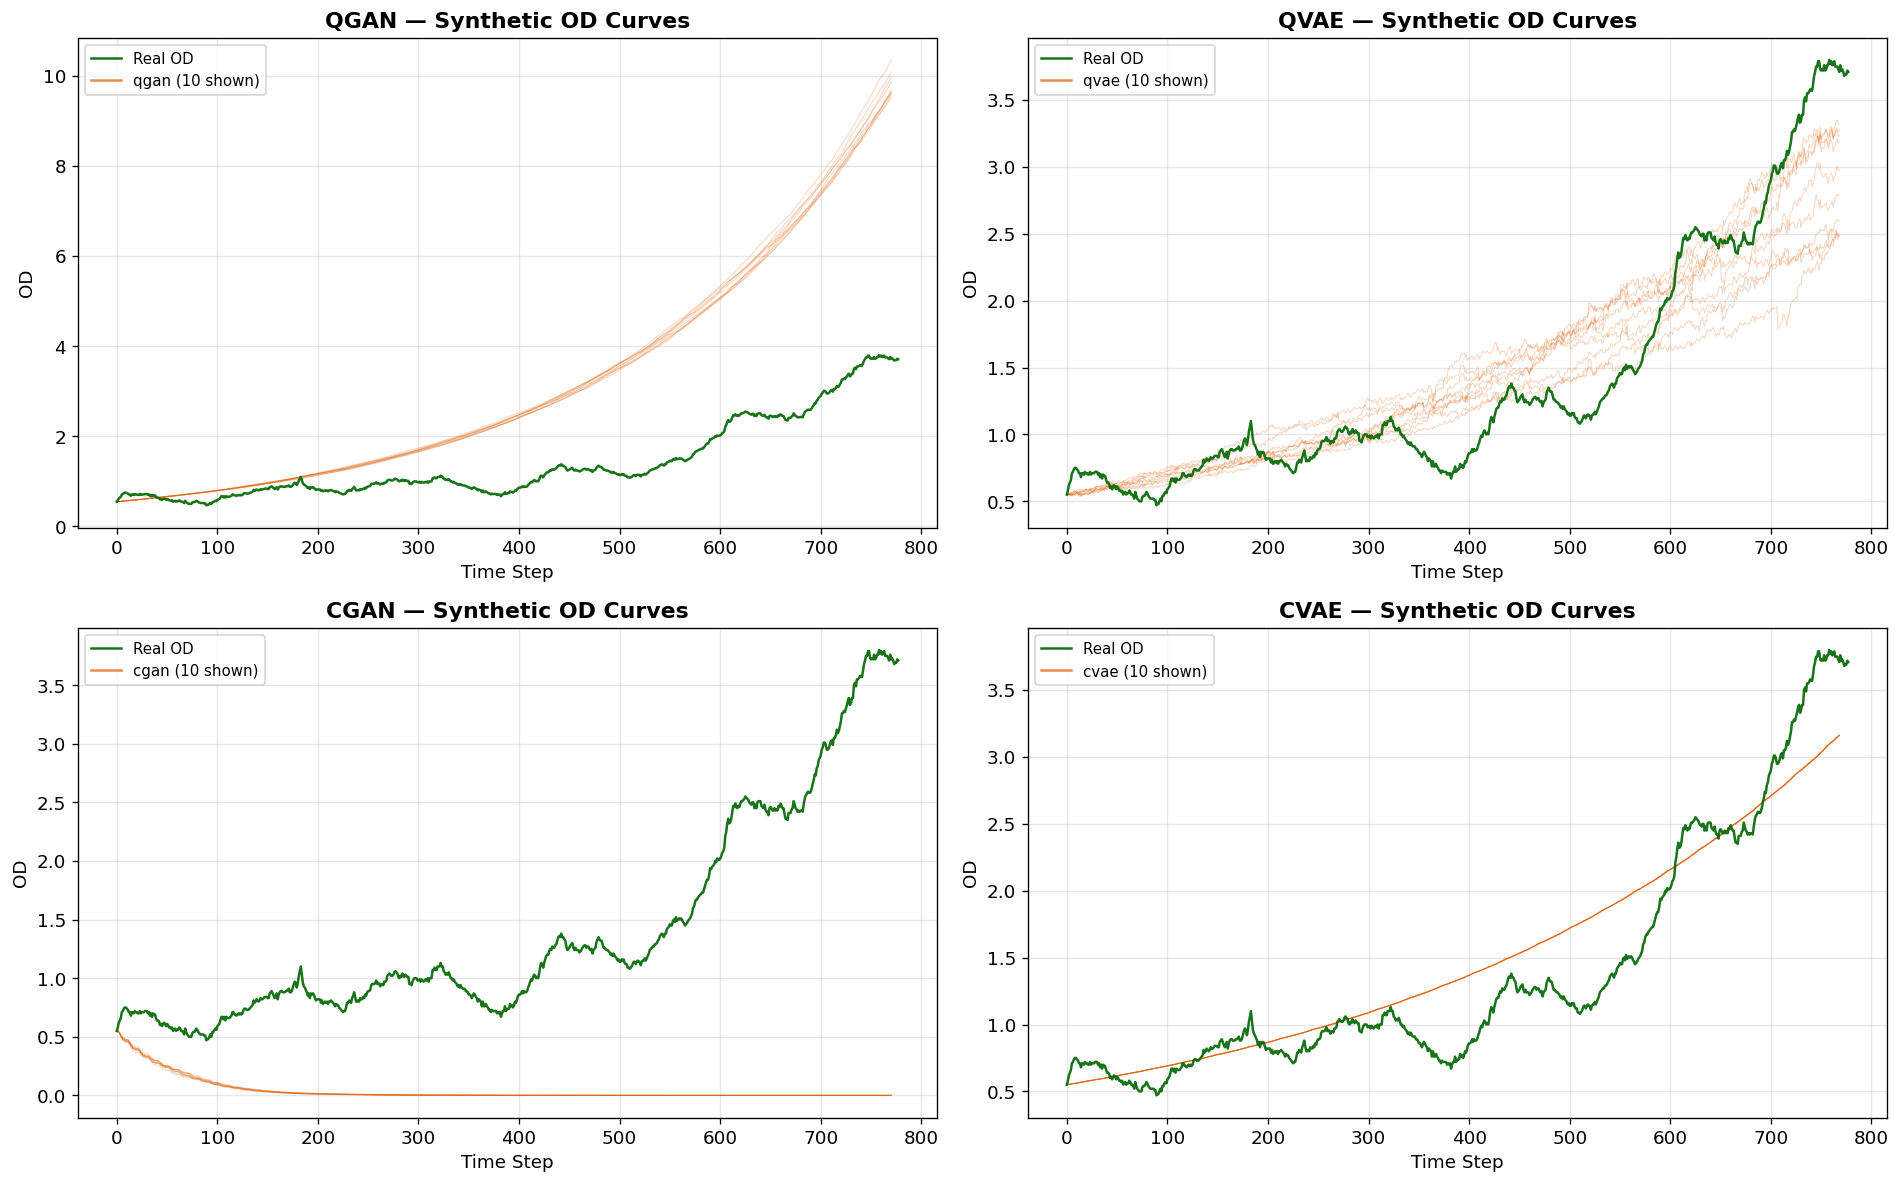

Saved: synthetic_od_curves.png


In [22]:
# ── 15. SAMPLE VISUALIZATION: synthetic vs real OD curves ────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (model_name, info) in zip(axes, MODELS_INFO.items()):
    save_dir = CKPT_DIR / info['subdir']
    sample_path = save_dir / f'size50_seed{GEN_SEEDS[0]}.npz'
    if not sample_path.exists():
        ax.set_title(f'{model_name} — not generated')
        continue

    data = np.load(sample_path, allow_pickle=True)
    od_curves = data['od_curves']

    ax.plot(raw_od, color=THEME_PRIMARY, linewidth=1.5, alpha=0.9, label='Real OD', zorder=3)
    for i, curve in enumerate(od_curves[:10]):
        ax.plot(curve, color=THEME_SYNTH, alpha=0.25, linewidth=0.6)
    ax.plot([], [], color=THEME_SYNTH, alpha=0.7, label=f'{model_name} (10 shown)')
    ax.set_title(f'{model_name.upper()} — Synthetic OD Curves', fontweight='bold')
    ax.set_xlabel('Time Step'); ax.set_ylabel('OD')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'synthetic_od_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: synthetic_od_curves.png')

---
# Section A: Synthetic Data Quality

Statistical and visual characterization of generated distributions before LSTM evaluation.

**Metrics:** MMD (Gretton et al. 2012), EMD (Wasserstein), stylized facts (Cont 2001): ACF RMSE, volatility clustering RMSE, leverage effect RMSE, kurtosis error.

In [23]:
# ── A1. QUALITY METRIC UTILITIES ────────────────────────────────────────────
from scipy.stats import gaussian_kde, kurtosis as scipy_kurtosis

def mmd_rbf(real_ld, synth_ld):
    """Maximum Mean Discrepancy with median-heuristic RBF kernel (Gretton et al. 2012)."""
    x = real_ld.reshape(-1, 1).astype(np.float64)
    y = synth_ld.reshape(-1, 1).astype(np.float64)
    # Median heuristic for bandwidth
    all_pts = np.vstack([x, y])
    dists   = np.abs(all_pts[:, None] - all_pts[None, :]).squeeze()
    gamma   = 1.0 / (2.0 * (np.median(dists) ** 2) + 1e-10)
    def rbf(A, B):
        return np.exp(-gamma * ((A - B.T) ** 2))
    XX = rbf(x, x); YY = rbf(y, y); XY = rbf(x, y)
    return float(XX.mean() + YY.mean() - 2 * XY.mean())

def compute_stylized_facts(real_ld, synth_ld, n_lags=18):
    """Cont (2001) stylized facts + MMD."""
    r, s = np.asarray(real_ld, np.float64), np.asarray(synth_ld, np.float64)
    def acf_vals(x):
        return sm.tsa.acf(x, nlags=n_lags)[1:]
    def leverage(x):
        return [float(np.corrcoef(x[:-k], np.abs(x[k:]) ** 2)[0, 1])
                for k in range(1, n_lags + 1)]
    acf_r, acf_s         = acf_vals(r), acf_vals(s)
    acf_abs_r, acf_abs_s = acf_vals(np.abs(r)), acf_vals(np.abs(s))
    lev_r, lev_s         = leverage(r), leverage(s)
    return {
        'acf_rmse' : float(np.sqrt(np.mean((acf_r - acf_s) ** 2))),
        'vol_rmse' : float(np.sqrt(np.mean((acf_abs_r - acf_abs_s) ** 2))),
        'lev_rmse' : float(np.sqrt(np.mean((np.array(lev_r) - np.array(lev_s)) ** 2))),
        'emd'      : float(wasserstein_distance(r, s)),
        'kurt_err' : float(abs(scipy_kurtosis(s, fisher=True) - scipy_kurtosis(r, fisher=True))),
        'mmd'      : mmd_rbf(r, s),
    }

print('Quality metric utilities defined.')
print('Metrics: ACF RMSE, Volatility clustering RMSE, Leverage RMSE, EMD, Kurtosis error, MMD')

Quality metric utilities defined.
Metrics: ACF RMSE, Volatility clustering RMSE, Leverage RMSE, EMD, Kurtosis error, MMD


In [24]:
# ── A2. COMPUTE QUALITY METRICS FOR ALL MODELS ───────────────────────────────
# Uses the size-50 set (seed 0) as representative sample.

QUALITY_METRICS = {}

for model_name, info in MODELS_INFO.items():
    path = CKPT_DIR / info['subdir'] / f'size50_seed{GEN_SEEDS[0]}.npz'
    if not path.exists():
        print(f'  [{model_name}] file not found — skip.')
        continue
    data     = np.load(path, allow_pickle=True)
    ld_all   = np.concatenate([ld.astype(np.float64) for ld in data['ld_curves']])
    metrics  = compute_stylized_facts(growth_rate.astype(np.float64), ld_all)
    QUALITY_METRICS[model_name] = metrics
    print(f'{model_name.upper():6s}  '
          f'EMD={metrics["emd"]:.5f}  '
          f'MMD={metrics["mmd"]:.5f}  '
          f'ACF={metrics["acf_rmse"]:.4f}  '
          f'Vol={metrics["vol_rmse"]:.4f}  '
          f'Lev={metrics["lev_rmse"]:.4f}  '
          f'Kurt={metrics["kurt_err"]:.4f}')

quality_df = pd.DataFrame(QUALITY_METRICS).T.reset_index()
quality_df.columns = ['Model', 'ACF RMSE', 'Vol RMSE', 'Lev RMSE', 'EMD', 'Kurt Err', 'MMD']
quality_df['Model'] = quality_df['Model'].str.upper()
print('\nQuality metrics table:')
print(quality_df.to_string(index=False, float_format='{:.6f}'.format))

QGAN    EMD=0.01547  MMD=0.50279  ACF=0.0817  Vol=0.1416  Lev=0.0484  Kurt=1.4360
QVAE    EMD=0.00712  MMD=0.05132  ACF=0.1215  Vol=0.1477  Lev=0.0613  Kurt=2.3597
CGAN    EMD=0.02116  MMD=0.24599  ACF=0.3670  Vol=0.3958  Lev=0.3716  Kurt=2.2508
CVAE    EMD=0.01576  MMD=0.51358  ACF=0.2453  Vol=0.2951  Lev=0.2413  Kurt=1.8556

Quality metrics table:
Model  ACF RMSE  Vol RMSE  Lev RMSE      EMD  Kurt Err      MMD
 QGAN  0.081669  0.141590  0.048407 0.015472  1.436038 0.502785
 QVAE  0.121498  0.147718  0.061296 0.007117  2.359663 0.051322
 CGAN  0.366968  0.395817  0.371605 0.021156  2.250822 0.245985
 CVAE  0.245283  0.295079  0.241322 0.015755  1.855631 0.513576


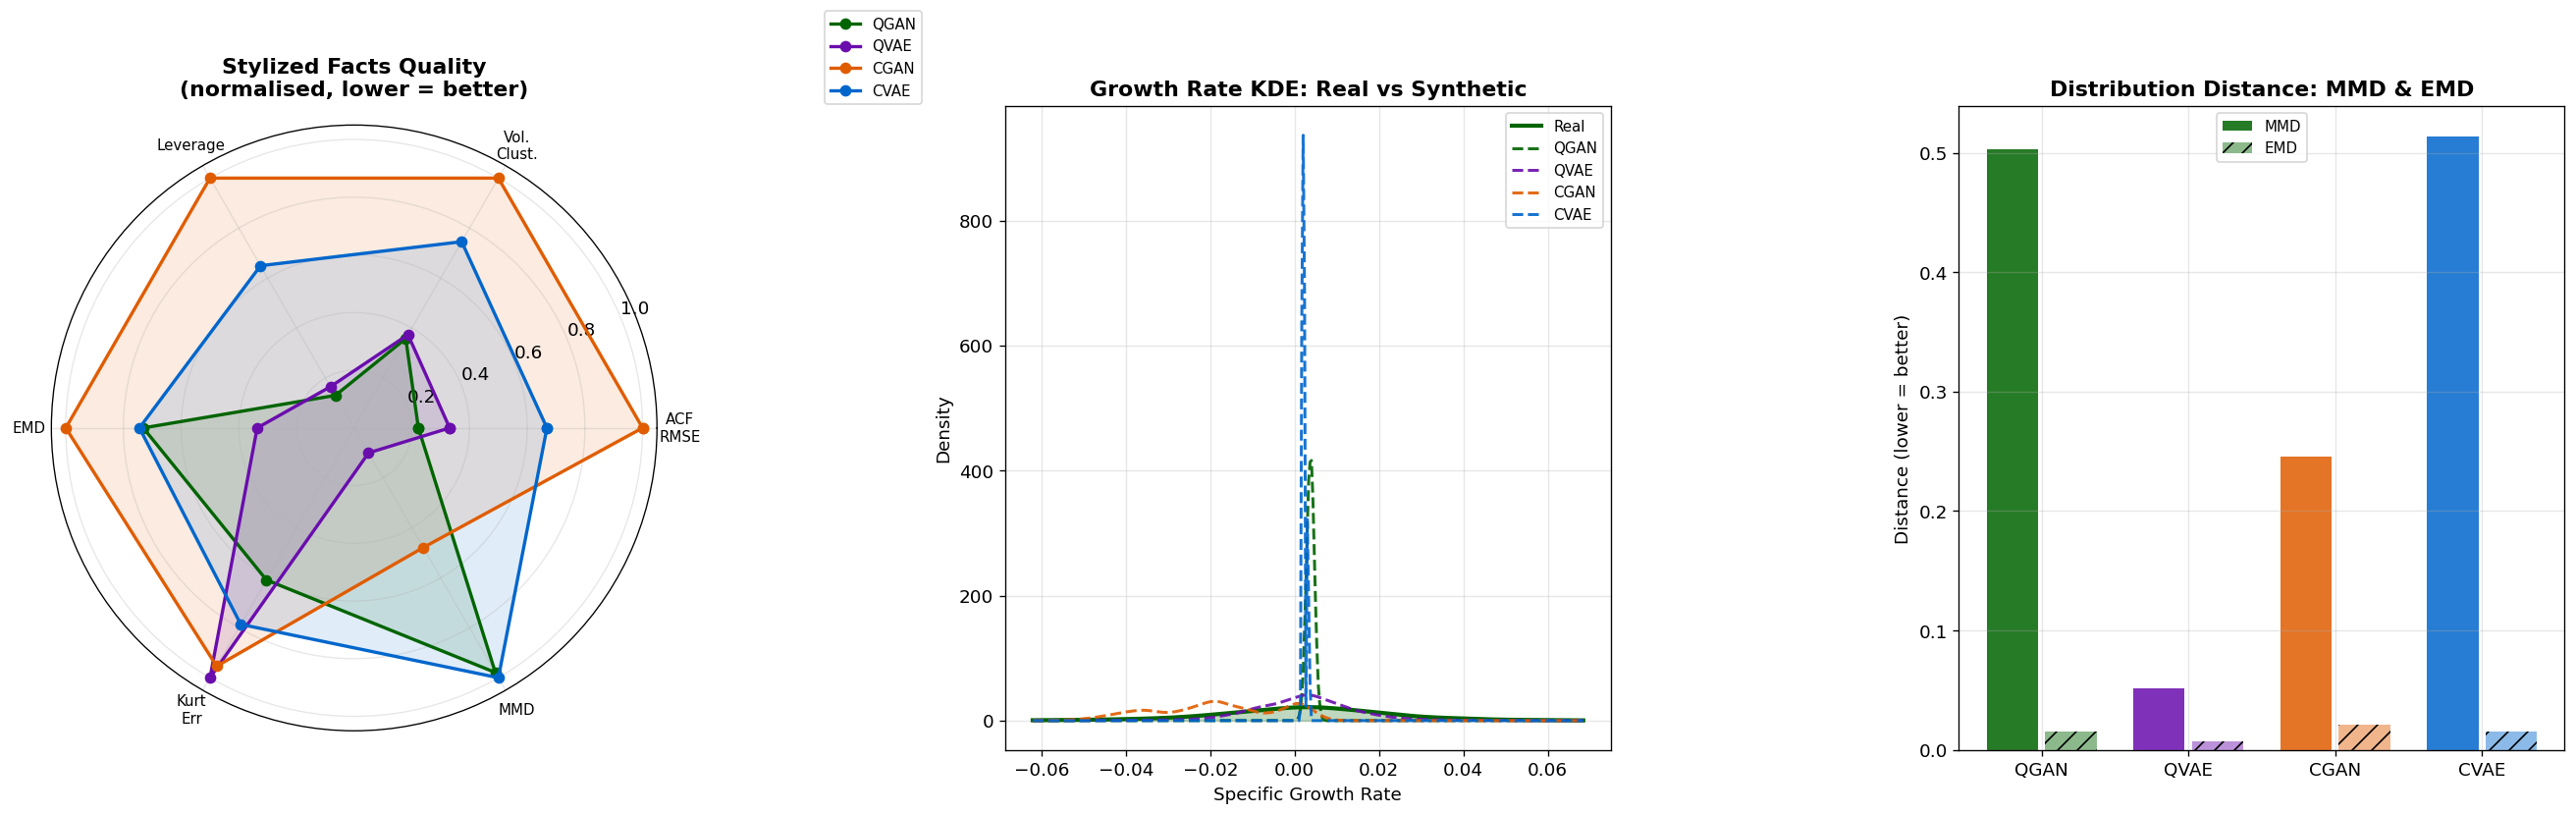

Saved: quality_radar_kde_mmd.png


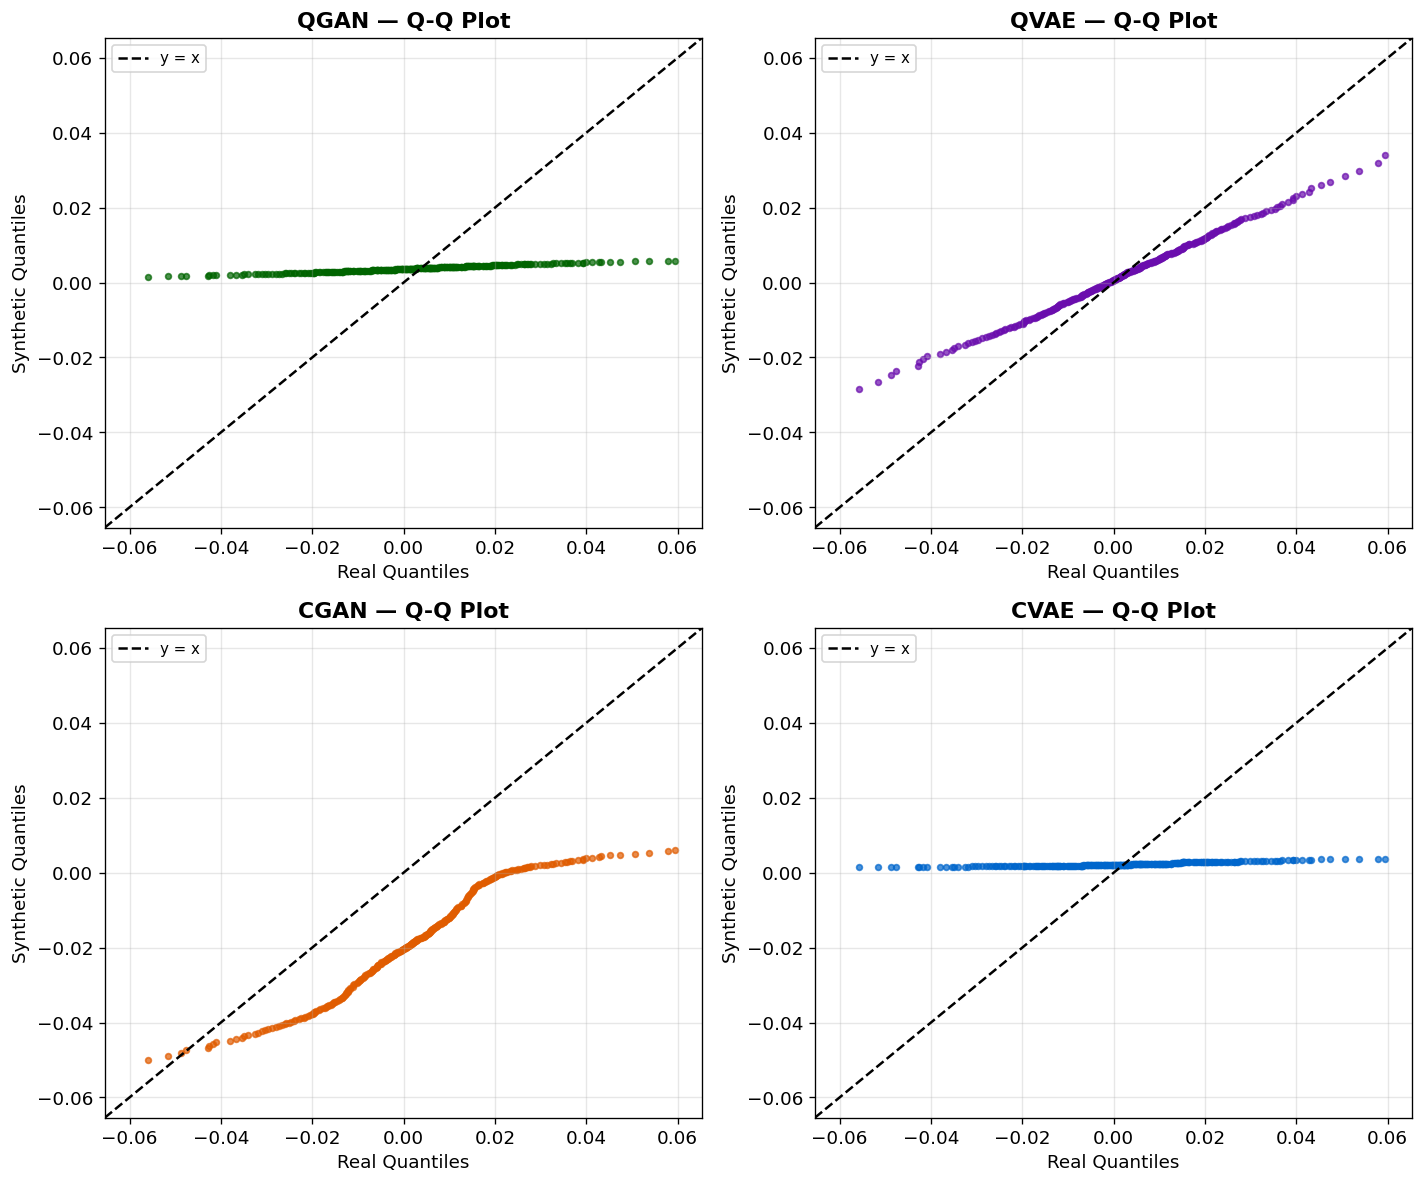

Saved: quality_qq_grid.png


In [25]:
# ── A3. RADAR CHART + KDE OVERLAY + Q-Q GRID ─────────────────────────────────
if not QUALITY_METRICS:
    print('No quality metrics computed — run A2 first.')
else:
    MODEL_COLORS = {'qgan': THEME_PRIMARY, 'qvae': '#6A0DAD',
                    'cgan': THEME_SYNTH,   'cvae': THEME_CLS}
    model_list   = list(QUALITY_METRICS.keys())

    # ── Radar chart ───────────────────────────────────────────────────────────
    categories  = ['ACF\nRMSE', 'Vol.\nClust.', 'Leverage', 'EMD', 'Kurt\nErr', 'MMD']
    metric_keys = ['acf_rmse', 'vol_rmse', 'lev_rmse', 'emd', 'kurt_err', 'mmd']
    n_cat = len(categories)
    angles = np.linspace(0, 2 * np.pi, n_cat, endpoint=False).tolist()
    angles += angles[:1]

    all_vals = np.array([[QUALITY_METRICS[m][k] for k in metric_keys] for m in model_list])
    col_max  = np.where(all_vals.max(axis=0) == 0, 1, all_vals.max(axis=0))
    norm_v   = all_vals / col_max

    fig = plt.figure(figsize=(22, 7))
    ax_r = fig.add_subplot(131, polar=True)
    for i, mn in enumerate(model_list):
        vals = norm_v[i].tolist() + [norm_v[i][0]]
        c = MODEL_COLORS[mn]
        ax_r.plot(angles, vals, 'o-', color=c, linewidth=2, label=mn.upper())
        ax_r.fill(angles, vals, color=c, alpha=0.12)
    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(categories, fontsize=9)
    ax_r.set_ylim(0, 1.05)
    ax_r.set_title('Stylized Facts Quality\n(normalised, lower = better)',
                   fontweight='bold', pad=18)
    ax_r.legend(loc='upper right', bbox_to_anchor=(1.45, 1.2), fontsize=9)

    # ── KDE overlay ──────────────────────────────────────────────────────────
    ax_k = fig.add_subplot(132)
    x_grid = np.linspace(np.percentile(growth_rate, 0.5), np.percentile(growth_rate, 99.5), 400)
    kde_real = gaussian_kde(growth_rate)(x_grid)
    ax_k.fill_between(x_grid, kde_real, alpha=0.25, color=THEME_PRIMARY)
    ax_k.plot(x_grid, kde_real, color=THEME_PRIMARY, linewidth=2.5, label='Real')
    for mn in model_list:
        path = CKPT_DIR / MODELS_INFO[mn]['subdir'] / f'size50_seed{GEN_SEEDS[0]}.npz'
        if not path.exists(): continue
        ld_all = np.concatenate([ld.astype(np.float64)
                                 for ld in np.load(path, allow_pickle=True)['ld_curves']])
        ld_clip = np.clip(ld_all, x_grid.min(), x_grid.max())
        kde_s = gaussian_kde(ld_clip)(x_grid)
        ax_k.plot(x_grid, kde_s, color=MODEL_COLORS[mn], linewidth=1.8,
                  linestyle='--', label=mn.upper(), alpha=0.9)
    ax_k.set_xlabel('Specific Growth Rate'); ax_k.set_ylabel('Density')
    ax_k.set_title('Growth Rate KDE: Real vs Synthetic', fontweight='bold')
    ax_k.legend(fontsize=9)

    # ── MMD bar chart ────────────────────────────────────────────────────────
    ax_m = fig.add_subplot(133)
    mmd_vals  = [QUALITY_METRICS[mn]['mmd']  for mn in model_list]
    emd_vals  = [QUALITY_METRICS[mn]['emd']  for mn in model_list]
    bar_colors = [MODEL_COLORS[mn] for mn in model_list]
    x_pos = np.arange(len(model_list))
    bars1 = ax_m.bar(x_pos - 0.2, mmd_vals, 0.35, label='MMD', color=bar_colors, alpha=0.85)
    bars2 = ax_m.bar(x_pos + 0.2, emd_vals, 0.35, label='EMD', color=bar_colors,
                     alpha=0.45, hatch='//')
    ax_m.set_xticks(x_pos); ax_m.set_xticklabels([m.upper() for m in model_list])
    ax_m.set_ylabel('Distance (lower = better)')
    ax_m.set_title('Distribution Distance: MMD & EMD', fontweight='bold')
    ax_m.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'quality_radar_kde_mmd.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: quality_radar_kde_mmd.png')

    # ── 2×2 Q-Q grid ─────────────────────────────────────────────────────────
    probs = np.linspace(0.01, 0.99, 300)
    real_q = np.quantile(growth_rate, probs)
    fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
    for ax, mn in zip(axes2.flatten(), model_list):
        path = CKPT_DIR / MODELS_INFO[mn]['subdir'] / f'size50_seed{GEN_SEEDS[0]}.npz'
        if not path.exists(): ax.set_visible(False); continue
        ld_all  = np.concatenate([ld.astype(np.float64)
                                  for ld in np.load(path, allow_pickle=True)['ld_curves']])
        synth_q = np.quantile(ld_all, probs)
        lim = max(np.abs(real_q).max(), np.abs(synth_q).max()) * 1.1
        ax.scatter(real_q, synth_q, color=MODEL_COLORS[mn], s=12, alpha=0.7)
        ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1.5, label='y = x')
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_xlabel('Real Quantiles'); ax.set_ylabel('Synthetic Quantiles')
        ax.set_title(f'{mn.upper()} — Q-Q Plot', fontweight='bold')
        ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'quality_qq_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: quality_qq_grid.png')

In [26]:
# ── 16. LSTM ARCHITECTURE ─────────────────────────────────────────────────────

class ODLSTM(nn.Module):
    """2-layer LSTM for one-step-ahead log-return prediction."""
    def __init__(self, hidden=LSTM_HIDDEN, n_layers=LSTM_LAYERS, dropout=LSTM_DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, n_layers,
                            batch_first=True,
                            dropout=dropout if n_layers > 1 else 0)
        self.fc   = nn.Linear(hidden, 1)

    def forward(self, x):
        # x: (batch, seq_len, 1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)   # predict next step


def make_lstm_dataset(series, lookback):
    """Sliding-window dataset from a 1D log-delta series."""
    X, y = [], []
    for i in range(len(series) - lookback):
        X.append(series[i : i + lookback])
        y.append(series[i + lookback])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def train_lstm(model, X_train, y_train, epochs, lr, batch_size=64, device='cpu'):
    model  = model.to(device)
    ds     = TensorDataset(torch.from_numpy(X_train).unsqueeze(-1),
                           torch.from_numpy(y_train))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt    = optim.Adam(model.parameters(), lr=lr)
    crit   = nn.MSELoss()
    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
    return model.cpu()


def evaluate_lstm(model, X_test, y_test, device='cpu'):
    model.eval().to(device)
    with torch.no_grad():
        X_t = torch.from_numpy(X_test).unsqueeze(-1).to(device)
        preds = model(X_t).cpu().numpy()
    mse  = float(np.mean((preds - y_test) ** 2))
    mape = float(np.mean(np.abs(preds - y_test) / (np.abs(y_test) + 1e-8)))
    return {'mse': mse, 'mape': mape, 'preds': preds}


print(f'LSTM: {LSTM_LAYERS}L × {LSTM_HIDDEN}H, lookback={LOOKBACK}, epochs={LSTM_EPOCHS}')
print(f'Params: {sum(p.numel() for p in ODLSTM().parameters())}')

LSTM: 2L × 64H, lookback=20, epochs=50
Params: 50497


In [27]:
# ── 17. TRAIN / TEST SPLIT (real data) ───────────────────────────────────────

n_train = int(len(growth_rate) * TRAIN_FRAC)
real_train_ld = growth_rate[:n_train]
real_test_ld  = growth_rate[n_train:]

X_test, y_test = make_lstm_dataset(real_test_ld, LOOKBACK)
# Need a burn-in from the end of training to start test predictions
X_test_full = np.vstack([
    make_lstm_dataset(np.concatenate([real_train_ld[-LOOKBACK:], real_test_ld]), LOOKBACK)[0]
])
X_test_full, y_test_full = make_lstm_dataset(
    np.concatenate([real_train_ld[-LOOKBACK:], real_test_ld]), LOOKBACK
)

print(f'Total growth rate points: {len(growth_rate)}')
print(f'Train: {len(real_train_ld)}  Test: {len(real_test_ld)}')
print(f'X_test shape: {X_test_full.shape}  y_test shape: {y_test_full.shape}')

Total growth rate points: 777
Train: 621  Test: 156
X_test shape: (156, 20)  y_test shape: (156,)


In [28]:
# ── 18. BASELINE LSTM (real data only) ───────────────────────────────────────

baseline_ckpt = CKPT_DIR / 'lstm_results' / 'baseline.json'

if not FORCE_LSTM and baseline_ckpt.exists():
    with open(baseline_ckpt) as f:
        baseline_results = json.load(f)
    print(f'Baseline loaded: MSE={baseline_results["mse"]:.6f}, MAPE={baseline_results["mape"]:.4f}')
else:
    print('Training baseline LSTM (real data only)...')
    torch.manual_seed(0)
    X_train_base, y_train_base = make_lstm_dataset(real_train_ld, LOOKBACK)
    lstm_base = train_lstm(ODLSTM(), X_train_base, y_train_base,
                           LSTM_EPOCHS, LSTM_LR)
    baseline_results = evaluate_lstm(lstm_base, X_test_full, y_test_full)
    _baseline_preds = baseline_results.pop('preds')
    np.save(baseline_ckpt.with_suffix('.npy'), _baseline_preds)
    with open(baseline_ckpt, 'w') as f:
        json.dump(baseline_results, f, indent=2)
    print(f'Baseline — MSE={baseline_results["mse"]:.6f}, MAPE={baseline_results["mape"]:.4f}')

Baseline loaded: MSE=0.000105, MAPE=1.4415


In [29]:
# ── 19. LSTM EXPERIMENT LOOP ──────────────────────────────────────────────────
# For each (model, n_synth, seed): augment real train with synthetic,
# train LSTM, evaluate on real test set.

all_results = {}   # key: (model, n_synth, seed) -> {mse, mape}

for model_name, info in MODELS_INFO.items():
    save_dir = CKPT_DIR / info['subdir']
    all_results[model_name] = {}

    for n_synth in SYNTH_SIZES:
        all_results[model_name][n_synth] = []

        for seed in GEN_SEEDS:
            result_key  = f'{model_name}_size{n_synth}_seed{seed}'
            result_path = CKPT_DIR / 'lstm_results' / f'{result_key}.json'

            if not FORCE_LSTM and result_path.exists():
                with open(result_path) as f:
                    res = json.load(f)
                all_results[model_name][n_synth].append(res)
                print(f'  [{result_key}] loaded: MSE={res["mse"]:.6f}')
                continue

            # Load synthetic log-delta curves
            synth_path = save_dir / f'size{n_synth}_seed{seed}.npz'
            if not synth_path.exists():
                print(f'  [{result_key}] synthetic file missing — skip.')
                continue

            data     = np.load(synth_path, allow_pickle=True)
            ld_list  = list(data['ld_curves'])

            # Per-curve windowing (D-07, D-08): no window spans curve boundaries
            X_parts, y_parts = [], []
            # Window real training data independently
            X_r, y_r = make_lstm_dataset(real_train_ld, LOOKBACK)
            X_parts.append(X_r); y_parts.append(y_r)
            # Window each synthetic curve independently
            for ld in ld_list:
                if len(ld) > LOOKBACK:  # guard: curve must be longer than lookback
                    X_s, y_s = make_lstm_dataset(ld.astype(np.float32), LOOKBACK)
                    X_parts.append(X_s); y_parts.append(y_s)
            X_aug = np.concatenate(X_parts, axis=0)
            y_aug = np.concatenate(y_parts, axis=0)

            print(f'  [{result_key}] Training LSTM on {len(X_aug)} windows '
                  f'(real={len(real_train_ld)-LOOKBACK}, +synth={len(X_aug)-(len(real_train_ld)-LOOKBACK)})...')

            torch.manual_seed(seed)
            lstm_model = train_lstm(ODLSTM(), X_aug, y_aug, LSTM_EPOCHS, LSTM_LR)
            res = evaluate_lstm(lstm_model, X_test_full, y_test_full)
            _preds = res.pop('preds')
            np.save(result_path.with_suffix('.npy'), _preds)

            with open(result_path, 'w') as f:
                json.dump(res, f, indent=2)

            all_results[model_name][n_synth].append(res)
            print(f'    MSE={res["mse"]:.6f}, MAPE={res["mape"]:.4f}')

print('\nLSTM experiment loop complete.')

#Runtime ~12 hours. DO NOT RUN UNLESS YOU HAVE TOO!

  [qgan_size50_seed42] loaded: MSE=0.000102
  [qgan_size50_seed137] loaded: MSE=0.000100
  [qgan_size50_seed271] loaded: MSE=0.000098
  [qgan_size150_seed42] loaded: MSE=0.000102
  [qgan_size150_seed137] loaded: MSE=0.000101
  [qgan_size150_seed271] loaded: MSE=0.000106
  [qgan_size250_seed42] loaded: MSE=0.000100
  [qgan_size250_seed137] loaded: MSE=0.000101
  [qgan_size250_seed271] loaded: MSE=0.000106
  [qvae_size50_seed42] loaded: MSE=0.000159
  [qvae_size50_seed137] loaded: MSE=0.000137
  [qvae_size50_seed271] loaded: MSE=0.000137
  [qvae_size150_seed42] loaded: MSE=0.000133
  [qvae_size150_seed137] loaded: MSE=0.000138
  [qvae_size150_seed271] loaded: MSE=0.000136
  [qvae_size250_seed42] loaded: MSE=0.000146
  [qvae_size250_seed137] loaded: MSE=0.000145
  [qvae_size250_seed271] loaded: MSE=0.000151
  [cgan_size50_seed42] loaded: MSE=0.000109
  [cgan_size50_seed137] loaded: MSE=0.000108
  [cgan_size50_seed271] loaded: MSE=0.000146
  [cgan_size150_seed42] loaded: MSE=0.000129
  [cg

In [30]:
# ── 20. RESULTS TABLE ─────────────────────────────────────────────────────────

rows = []
rows.append({'model': 'Baseline (real only)', 'n_synth': 0,
             'mse_mean': baseline_results['mse'], 'mse_std': 0.0,
             'mape_mean': baseline_results['mape'], 'mape_std': 0.0})

for model_name in MODELS_INFO:
    for n_synth in SYNTH_SIZES:
        runs = all_results.get(model_name, {}).get(n_synth, [])
        if not runs:
            continue
        mses  = [r['mse']  for r in runs]
        mapes = [r['mape'] for r in runs]
        rows.append({
            'model':     model_name.upper(),
            'n_synth':   n_synth,
            'mse_mean':  np.mean(mses),
            'mse_std':   np.std(mses),
            'mape_mean': np.mean(mapes),
            'mape_std':  np.std(mapes),
        })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False, float_format='{:.6f}'.format))

               model  n_synth  mse_mean  mse_std  mape_mean  mape_std
Baseline (real only)        0  0.000105 0.000000   1.441494  0.000000
                QGAN       50  0.000100 0.000002   2.562990  0.287620
                QGAN      150  0.000103 0.000002   2.675636  0.242965
                QGAN      250  0.000102 0.000002   2.561133  0.219602
                QVAE       50  0.000144 0.000011   4.592472  0.718752
                QVAE      150  0.000136 0.000002   5.305979  1.503242
                QVAE      250  0.000147 0.000003   4.825876  0.847555
                CGAN       50  0.000121 0.000018   3.872129  2.309156
                CGAN      150  0.000125 0.000018   3.313474  0.527713
                CGAN      250  0.000115 0.000007   2.839713  0.937409
                CVAE       50  0.000099 0.000002   1.842399  0.065198
                CVAE      150  0.000101 0.000001   1.919259  0.117435
                CVAE      250  0.000107 0.000003   2.222463  0.190000


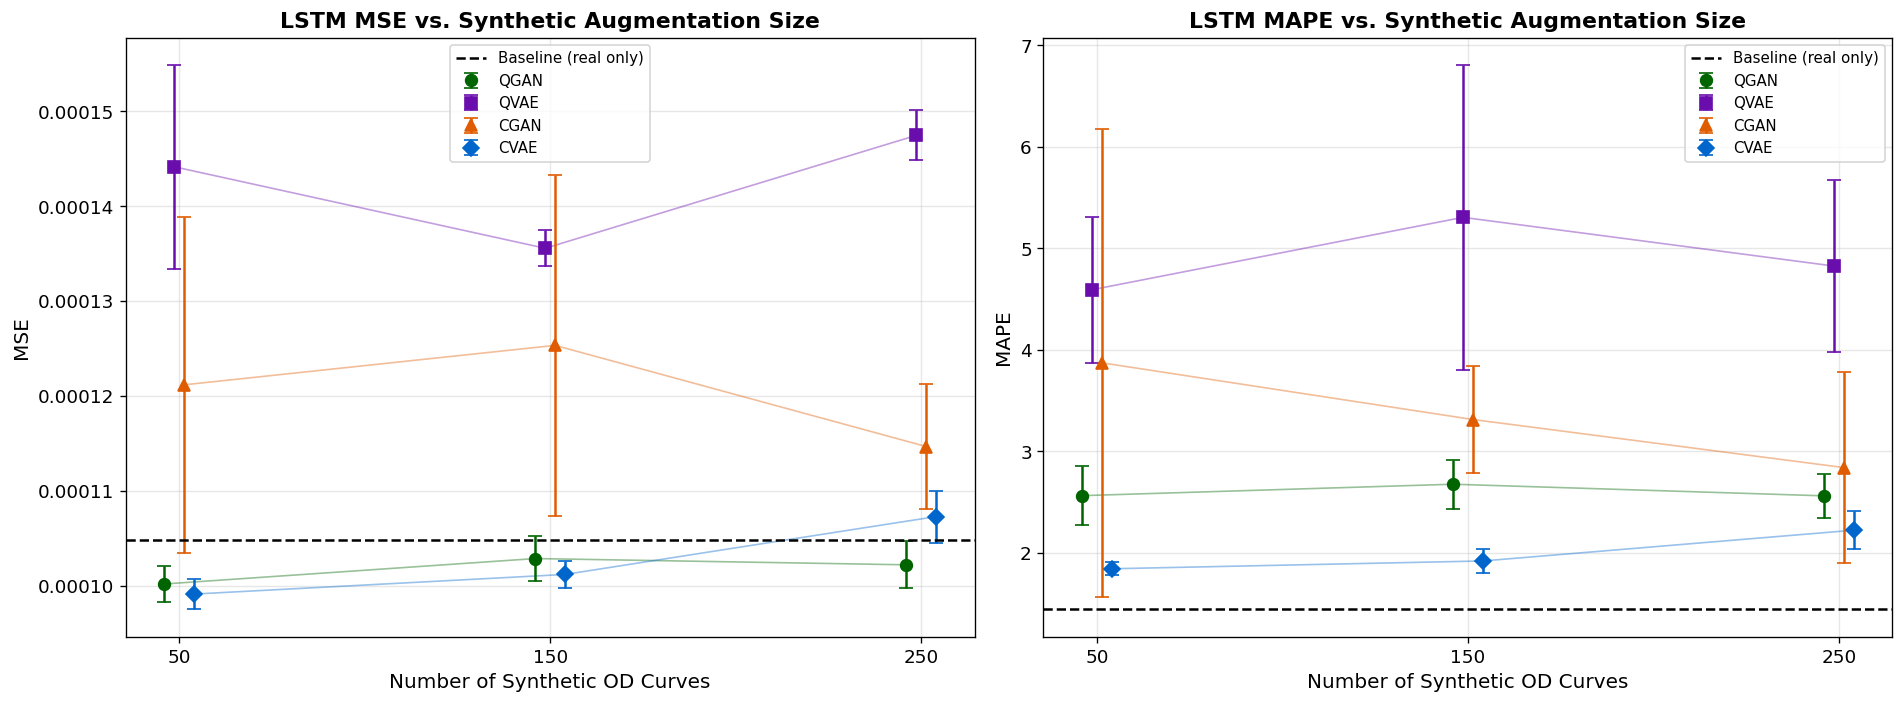

Saved: lstm_comparison.png


In [31]:
# ── 21. COMPARISON PLOTS ──────────────────────────────────────────────────────

model_names  = ['QGAN', 'QVAE', 'CGAN', 'CVAE']
colors       = [THEME_PRIMARY, '#6A0DAD', THEME_SYNTH, THEME_CLS]
markers      = ['o', 's', '^', 'D']
x_positions  = np.array(SYNTH_SIZES, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for metric, ax, ylabel in [('mse', axes[0], 'MSE'),
                             ('mape', axes[1], 'MAPE')]:
    # Baseline
    base_val = baseline_results[metric]
    ax.axhline(base_val, color='black', linestyle='--', linewidth=1.5,
               label='Baseline (real only)', zorder=5)

    offsets = np.linspace(-0.04, 0.04, len(model_names)) * (x_positions[1] - x_positions[0])

    for i, (mn, color, marker, offset) in enumerate(
            zip(model_names, colors, markers, offsets)):
        subset = results_df[results_df['model'] == mn]
        if subset.empty:
            continue
        means = subset[f'{metric}_mean'].values
        stds  = subset[f'{metric}_std'].values
        xs    = subset['n_synth'].values.astype(float) + offset
        ax.errorbar(xs, means, yerr=stds, fmt=marker, color=color,
                    label=mn, capsize=4, linewidth=1.5, markersize=7, zorder=4)
        ax.plot(xs, means, '-', color=color, alpha=0.4, linewidth=1)

    ax.set_xlabel('Number of Synthetic OD Curves', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'LSTM {ylabel} vs. Synthetic Augmentation Size', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xticks(SYNTH_SIZES)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lstm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lstm_comparison.png')

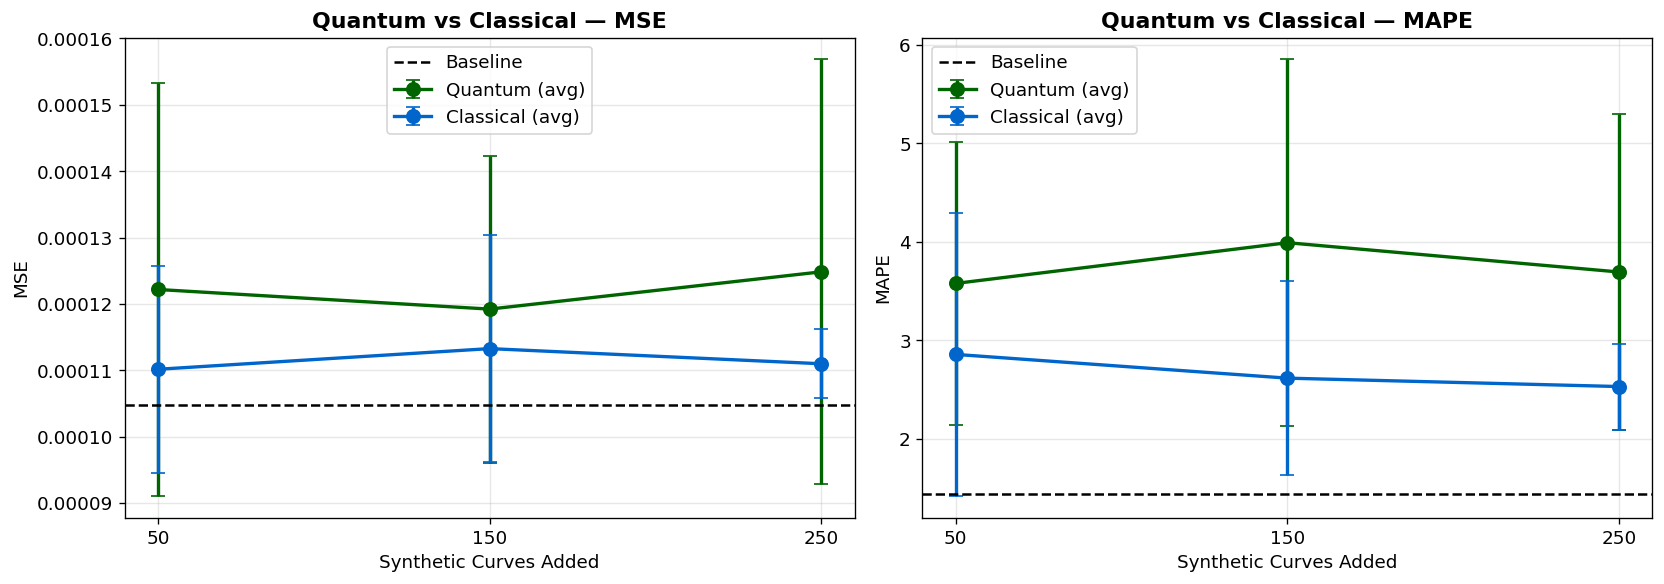

Saved: quantum_vs_classical.png


In [32]:
# ── 22. QUANTUM vs CLASSICAL SUMMARY ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel in [('mse', axes[0], 'MSE'), ('mape', axes[1], 'MAPE')]:
    pass  # assigned below

for ax, metric, ylabel in [(axes[0], 'mse', 'MSE'), (axes[1], 'mape', 'MAPE')]:
    quantum  = results_df[results_df['model'].isin(['QGAN', 'QVAE'])]
    classical = results_df[results_df['model'].isin(['CGAN', 'CVAE'])]

    for grp, color, label in [(quantum, THEME_PRIMARY, 'Quantum (avg)'),
                               (classical, THEME_CLS, 'Classical (avg)')]:
        if grp.empty:
            continue
        agg = grp.groupby('n_synth')[f'{metric}_mean'].agg(['mean', 'std']).reset_index()
        ax.errorbar(agg['n_synth'], agg['mean'], yerr=agg['std'],
                    fmt='-o', color=color, label=label, capsize=4, linewidth=2, markersize=8)

    ax.axhline(baseline_results[metric], color='black', linestyle='--',
               linewidth=1.5, label='Baseline')
    ax.set_xlabel('Synthetic Curves Added')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Quantum vs Classical — {ylabel}', fontweight='bold')
    ax.legend()
    ax.set_xticks(SYNTH_SIZES)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quantum_vs_classical.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: quantum_vs_classical.png')

In [33]:
# ── PAR_LIGHT ABLATION: Generate Synthetic Data ─────────────────────────────
# Generates ablation curves for all 4 models using no-PAR variants where applicable.
# Uses a single representative size and seed (ablation, not full experiment).

FORCE_ABLATION     = True
ABLATION_SYNTH_DIR = CKPT_DIR / 'synthetic_ablation'
ABLATION_N_SYNTH   = 150   # representative augmentation size for comparison
ABLATION_SEED      = 42

print('Generating no-PAR ablation synthetic data...')

for model_name, info in ABLATION_MODELS_INFO.items():
    model_dir = ABLATION_SYNTH_DIR / info['subdir']
    model_dir.mkdir(parents=True, exist_ok=True)

    out_path = model_dir / f'size{ABLATION_N_SYNTH}_seed{ABLATION_SEED}.npz'

    if out_path.exists() and not FORCE_ABLATION:
        print(f'  {model_name}: loading cached ablation curves')
        data = np.load(out_path, allow_pickle=True)
        od_curves = data['od_curves']
        ld_curves = data['ld_curves']
    else:
        print(f'  {model_name}: generating {ABLATION_N_SYNTH} curves (seed={ABLATION_SEED})...')
        od_curves, ld_curves = [], []
        for k in range(ABLATION_N_SYNTH):
            curve_seed = ABLATION_SEED + k
            try:
                od, gr = info['fn'](seed=curve_seed)
                od_curves.append(od)
                ld_curves.append(gr)
            except Exception as e:
                print(f'    Curve {k} failed: {e}')
        np.savez_compressed(out_path,
                            od_curves=np.array(od_curves, dtype=object),
                            ld_curves=np.array(ld_curves, dtype=object))

    data = np.load(out_path, allow_pickle=True)
    print(f'  {model_name}: {len(data["od_curves"])} curves ready → {out_path}')

print('Ablation data generation complete.')


Generating no-PAR ablation synthetic data...
  qgan_no_par: generating 150 curves (seed=42)...
  qgan_no_par: 150 curves ready → checkpoints/synthetic_ablation/qgan_no_par/size150_seed42.npz
  cgan_no_par: generating 150 curves (seed=42)...
  cgan_no_par: 150 curves ready → checkpoints/synthetic_ablation/cgan_no_par/size150_seed42.npz
  qvae: generating 150 curves (seed=42)...
  qvae: 150 curves ready → checkpoints/synthetic_ablation/qvae/size150_seed42.npz
  cvae: generating 150 curves (seed=42)...
  cvae: 150 curves ready → checkpoints/synthetic_ablation/cvae/size150_seed42.npz
Ablation data generation complete.


In [34]:
# ── PAR_LIGHT ABLATION: LSTM Evaluation ─────────────────────────────────────
# Run LSTM augmentation experiment for ablation curves.
# Mirrors the main experiment loop pattern (cell 19) using ABLATION_MODELS_INFO.

print('Running ablation LSTM evaluation...')
ablation_results = {}

for model_name, info in ABLATION_MODELS_INFO.items():
    model_dir    = ABLATION_SYNTH_DIR / info['subdir']
    ablation_key = f'ablation_{model_name}'
    result_path  = CKPT_DIR / 'lstm_results' / f'{ablation_key}_size{ABLATION_N_SYNTH}_seed{ABLATION_SEED}.json'
    result_path.parent.mkdir(parents=True, exist_ok=True)

    if not FORCE_ABLATION and result_path.exists():
        with open(result_path) as f:
            res = json.load(f)
        ablation_results[model_name] = {'mse': res['mse'], 'mape': res['mape']}
        print(f'  {model_name}: loaded cached — MSE={res["mse"]:.6f}, MAPE={res["mape"]:.4f}')
        continue

    synth_path = model_dir / f'size{ABLATION_N_SYNTH}_seed{ABLATION_SEED}.npz'
    if not synth_path.exists():
        print(f'  {model_name}: ablation synthetic file missing — skipping.')
        ablation_results[model_name] = {'mse': float('nan'), 'mape': float('nan')}
        continue

    data    = np.load(synth_path, allow_pickle=True)
    ld_list = list(data['ld_curves'])

    # Per-curve windowing (D-07, D-08): no window spans curve boundaries
    X_parts, y_parts = [], []
    # Window real training data independently
    X_r, y_r = make_lstm_dataset(real_train_ld, LOOKBACK)
    X_parts.append(X_r); y_parts.append(y_r)
    # Window each synthetic curve independently
    for ld in ld_list:
        if len(ld) > LOOKBACK:  # guard: curve must be longer than lookback
            X_s, y_s = make_lstm_dataset(ld.astype(np.float32), LOOKBACK)
            X_parts.append(X_s); y_parts.append(y_s)
    X_aug = np.concatenate(X_parts, axis=0)
    y_aug = np.concatenate(y_parts, axis=0)

    print(f'  {model_name}: training LSTM on {len(X_aug)} windows...')
    torch.manual_seed(ABLATION_SEED)
    lstm_model = train_lstm(ODLSTM(), X_aug, y_aug, LSTM_EPOCHS, LSTM_LR)
    res = evaluate_lstm(lstm_model, X_test_full, y_test_full)
    _preds = res.pop('preds')
    np.save(result_path.with_suffix('.npy'), _preds)
    with open(result_path, 'w') as f:
        json.dump(res, f, indent=2)

    ablation_results[model_name] = {'mse': res['mse'], 'mape': res['mape']}
    print(f'  {model_name}: MSE={res["mse"]:.6f}, MAPE={res["mape"]:.4f}')

print('Ablation LSTM evaluation complete.')


Running ablation LSTM evaluation...
  qgan_no_par: training LSTM on 116101 windows...
  qgan_no_par: MSE=0.000118, MAPE=4.2295
  cgan_no_par: training LSTM on 116101 windows...
  cgan_no_par: MSE=0.000122, MAPE=2.3446
  qvae: training LSTM on 115801 windows...
  qvae: MSE=0.000133, MAPE=6.5654
  cvae: training LSTM on 115801 windows...
  cvae: MSE=0.000099, MAPE=1.8365
Ablation LSTM evaluation complete.


In [35]:
# ── PAR_LIGHT ABLATION: Collect With-PAR Results from Main Experiment ────────
# Load the main experiment results for the same size and seed for comparison.
# If main experiment hasn't been run yet (no saved JSON), uses NaN.

main_results = {}
for model_name in ['qgan', 'cgan', 'qvae', 'cvae']:
    result_path = CKPT_DIR / 'lstm_results' / f'{model_name}_size{ABLATION_N_SYNTH}_seed{ABLATION_SEED}.json'
    if result_path.exists():
        with open(result_path) as f:
            r = json.load(f)
        main_results[model_name] = {'mse': r['mse'], 'mape': r['mape']}
        print(f'  {model_name} (with-PAR): MSE={r["mse"]:.6f}, MAPE={r["mape"]:.4f}')
    else:
        main_results[model_name] = {'mse': float('nan'), 'mape': float('nan')}
        print(f'  {model_name} (with-PAR): no saved result — will show NaN (run main experiment first)')


  qgan (with-PAR): MSE=0.000102, MAPE=2.3594
  cgan (with-PAR): MSE=0.000129, MAPE=3.2769
  qvae (with-PAR): MSE=0.000133, MAPE=6.5654
  cvae (with-PAR): MSE=0.000099, MAPE=1.8365


In [36]:
# ── PAR_LIGHT ABLATION: Results Table ────────────────────────────────────────

rows = []
for model in ['qgan', 'cgan', 'qvae', 'cvae']:
    ablation_key = f'{model}_no_par' if model in ['qgan', 'cgan'] else model
    with_par     = main_results.get(model,        {'mse': float('nan'), 'mape': float('nan')})
    without_par  = ablation_results.get(ablation_key, {'mse': float('nan'), 'mape': float('nan')})

    is_vae = model in ['qvae', 'cvae']
    rows.append({
        'Model':            model.upper(),
        'With PAR MSE':     with_par['mse']    if not is_vae else 'N/A',
        'Without PAR MSE':  without_par['mse'],
        'Delta MSE':        (with_par['mse'] - without_par['mse']) if not is_vae else 0.0,
        'With PAR MAPE':    with_par['mape']   if not is_vae else 'N/A',
        'Without PAR MAPE': without_par['mape'],
    })

ablation_df = pd.DataFrame(rows)
print('\n=== PAR_LIGHT Ablation Results ===')
print(ablation_df.to_string(index=False))



=== PAR_LIGHT Ablation Results ===
Model With PAR MSE  Without PAR MSE  Delta MSE With PAR MAPE  Without PAR MAPE
 QGAN     0.000102         0.000118  -0.000016      2.359416          4.229539
 CGAN     0.000129         0.000122   0.000007      3.276866          2.344626
 QVAE          N/A         0.000133   0.000000           N/A          6.565375
 CVAE          N/A         0.000099   0.000000           N/A          1.836504


### PAR_LIGHT Ablation Summary

The table above compares LSTM forecasting performance when generative models are trained with
and without PAR_LIGHT conditioning. For VAE models (qVAE, cVAE), no PAR_LIGHT input is used
during generation, so the 'without PAR' condition is identical to the standard condition.
A positive Delta MSE indicates that PAR_LIGHT conditioning improved performance.


---
# Section B: Statistical Analysis of LSTM Predictions

**Tests:**
- **Diebold-Mariano** (Harvey-Leybourne-Newbold 1997): pairwise forecast accuracy comparison on the full error series — the standard test in forecasting literature.
- **Wilcoxon signed-rank**: non-parametric paired comparison across seeds.
- **Kruskal-Wallis + Dunn post-hoc**: non-parametric ANOVA across all models per augmentation size.
- **Cliff's delta**: ordinal effect size — interpretable at n=3 where p-values are unreliable.

**Plots:** Violin plots, improvement heatmap, prediction trajectory, residual QQ.

In [37]:
# ── B1. STATISTICAL TEST UTILITIES ──────────────────────────────────────────
from scipy.stats import wilcoxon, kruskal, t as t_dist, norm as norm_dist

def diebold_mariano(e1, e2, h=1):
    """
    Modified Diebold-Mariano test (Harvey, Leybourne & Newbold 1997).
    e1, e2: forecast error arrays for two models (same length T).
    Returns: (DM statistic, two-tailed p-value)
    """
    d    = e1 ** 2 - e2 ** 2       # MSE loss differential
    T    = len(d)
    dbar = d.mean()
    # Newey-West HAC variance (h-1 lags)
    gamma_0 = np.var(d, ddof=1)
    nw_sum  = sum(np.cov(d[k:], d[:-k])[0, 1] for k in range(1, h))
    V_d     = (gamma_0 + 2 * nw_sum) / T
    # HLN small-sample correction
    k_     = ((T + 1 - 2*h + h*(h-1)/T) / T) ** 0.5
    DM     = dbar / (k_ * np.sqrt(max(V_d, 1e-12)))
    p_val  = 2 * (1 - t_dist.cdf(abs(DM), df=T - 1))
    return float(DM), float(p_val)

def cliffs_delta(x, y):
    """Ordinal effect size (Cliff 1993). Range [-1, 1]; |d|>0.47 = large."""
    x, y = np.asarray(x), np.asarray(y)
    dom = sum(1 for xi in x for yi in y if xi > yi)
    sub = sum(1 for xi in x for yi in y if xi < yi)
    return (dom - sub) / (len(x) * len(y))

def dunn_test(groups, alpha=0.05):
    """
    Dunn (1964) post-hoc test after Kruskal-Wallis.
    groups: list of 1D arrays.
    Returns: matrix of p-values (Bonferroni corrected).
    """
    from itertools import combinations
    all_data = np.concatenate(groups)
    all_ranks = len(all_data) - np.argsort(np.argsort(all_data))  # reverse rank
    n_groups  = len(groups)
    N         = len(all_data)
    n_pairs   = n_groups * (n_groups - 1) // 2
    pvals     = np.ones((n_groups, n_groups))
    sizes, rank_sums = [], []
    idx = 0
    for g in groups:
        sizes.append(len(g))
        rank_sums.append(all_ranks[idx:idx+len(g)].mean())
        idx += len(g)
    for (i, j) in combinations(range(n_groups), 2):
        z = abs(rank_sums[i] - rank_sums[j]) / np.sqrt(
            N*(N+1)/12 * (1/sizes[i] + 1/sizes[j]))
        p_raw = 2 * (1 - norm_dist.cdf(z))
        p_bon = min(p_raw * n_pairs, 1.0)   # Bonferroni
        pvals[i, j] = pvals[j, i] = p_bon
    return pvals

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '.'
    return 'ns'

print('Statistical test utilities defined.')
print('  Diebold-Mariano (HLN) | Wilcoxon | Kruskal-Wallis | Dunn | Cliff\'s delta')

Statistical test utilities defined.
  Diebold-Mariano (HLN) | Wilcoxon | Kruskal-Wallis | Dunn | Cliff's delta


In [38]:
# ── B2. LOAD PREDICTIONS + RUN DM / WILCOXON / KRUSKAL-WALLIS TESTS ─────────

baseline_preds_path = CKPT_DIR / 'lstm_results' / 'baseline.npy'
dm_results = {}; wilcox_res = {}; kw_res = {}
if not baseline_preds_path.exists():
    print('Baseline predictions not found — set FORCE_LSTM=True and re-run Cell 20.')
else:
    baseline_preds = np.load(baseline_preds_path)
    baseline_errors = baseline_preds - y_test_full  # forecast errors

    dm_results  = {}   # (model, n_synth, seed) -> {DM, p, stars}
    wilcox_res  = {}   # (model, n_synth) -> {stat, p, stars, cliff}
    kw_res      = {}   # n_synth -> {H, p, stars, dunn}

    # ── Diebold-Mariano: each run vs baseline ─────────────────────────────────
    print('Diebold-Mariano tests (model vs baseline):')
    print(f'  {"Model":<8} {"N_synth":>8} {"Seed":>6} {"DM":>8} {"p-val":>8} {"Sig":>5}')

    for model_name in MODELS_INFO:
        dm_results[model_name] = {}
        for n_synth in SYNTH_SIZES:
            dm_results[model_name][n_synth] = []
            for seed in GEN_SEEDS:
                pred_path = CKPT_DIR / 'lstm_results' / \
                            f'{model_name}_size{n_synth}_seed{seed}.npy'
                if not pred_path.exists():
                    continue
                preds  = np.load(pred_path)
                errors = preds - y_test_full
                dm, p  = diebold_mariano(errors, baseline_errors)
                entry  = {'dm': dm, 'p': p, 'sig': sig_stars(p)}
                dm_results[model_name][n_synth].append(entry)
                print(f'  {model_name.upper():<8} {n_synth:>8} {seed:>6} '
                      f'{dm:>+8.3f} {p:>8.4f} {sig_stars(p):>5}')

    # ── Wilcoxon signed-rank: quantum vs classical (per size) ─────────────────
    print('\nWilcoxon signed-rank test (quantum vs classical MSE across seeds):')
    print('  Note: n=3 per condition — treat p-values as indicative only.')
    print(f'  {"Comparison":<22} {"N_synth":>8} {"stat":>8} {"p-val":>8} {"Cliff δ":>8} {"Sig":>5}')

    comparisons = [('qgan', 'cgan', 'qGAN vs cGAN'),
                   ('qvae', 'cvae', 'qVAE vs cVAE'),
                   ('qgan', 'qvae', 'qGAN vs qVAE')]

    for m1, m2, label in comparisons:
        wilcox_res[(m1, m2)] = {}
        for n_synth in SYNTH_SIZES:
            mse1 = [r['mse'] for r in all_results.get(m1, {}).get(n_synth, [])]
            mse2 = [r['mse'] for r in all_results.get(m2, {}).get(n_synth, [])]
            if len(mse1) < 2 or len(mse2) < 2:
                continue
            d_arr = np.array(mse1) - np.array(mse2)
            if np.all(d_arr == 0):
                continue
            try:
                stat, p = wilcoxon(mse1, mse2, alternative='two-sided')
            except ValueError:
                stat, p = np.nan, np.nan
            cd  = cliffs_delta(mse1, mse2)
            wilcox_res[(m1, m2)][n_synth] = {'stat': stat, 'p': p, 'cliff': cd}
            print(f'  {label:<22} {n_synth:>8} {stat:>8.3f} {p:>8.4f} '
                  f'{cd:>+8.3f} {sig_stars(p):>5}')

    # ── Kruskal-Wallis + Dunn across all 4 models ─────────────────────────────
    print('\nKruskal-Wallis across all 4 models (per augmentation size):')
    mn_order = list(MODELS_INFO.keys())

    for n_synth in SYNTH_SIZES:
        groups = []
        for mn in mn_order:
            mses = [r['mse'] for r in all_results.get(mn, {}).get(n_synth, [])]
            if mses:
                groups.append(np.array(mses))
        if len(groups) < 2:
            continue
        try:
            H, p = kruskal(*groups)
        except Exception:
            H, p = np.nan, np.nan
        pairwise = dunn_test(groups)
        kw_res[n_synth] = {'H': H, 'p': p, 'dunn': pairwise, 'models': mn_order[:len(groups)]}
        print(f'  N_synth={n_synth}: H={H:.3f}, p={p:.4f} {sig_stars(p)}')
        # Print Dunn pairwise
        names = [m.upper() for m in mn_order[:len(groups)]]
        for i in range(len(names)):
            for j in range(i+1, len(names)):
                print(f'    {names[i]} vs {names[j]}: p={pairwise[i,j]:.4f} {sig_stars(pairwise[i,j])}')

Diebold-Mariano tests (model vs baseline):
  Model     N_synth   Seed       DM    p-val   Sig
  QGAN           50     42   -0.332   0.7403    ns
  QGAN           50    137   -0.867   0.3875    ns
  QGAN           50    271   -1.358   0.1765    ns
  QGAN          150     42   -0.788   0.4318    ns
  QGAN          150    137   -0.743   0.4589    ns
  QGAN          150    271   +0.278   0.7812    ns
  QGAN          250     42   -1.124   0.2626    ns
  QGAN          250    137   -0.801   0.4242    ns
  QGAN          250    271   +0.180   0.8570    ns
  QVAE           50     42   +3.336   0.0011    **
  QVAE           50    137   +2.720   0.0073    **
  QVAE           50    271   +2.299   0.0228     *
  QVAE          150     42   +1.983   0.0492     *
  QVAE          150    137   +2.635   0.0093    **
  QVAE          150    271   +2.173   0.0313     *
  QVAE          250     42   +2.771   0.0063    **
  QVAE          250    137   +3.011   0.0030    **
  QVAE          250    271   +3.614   0

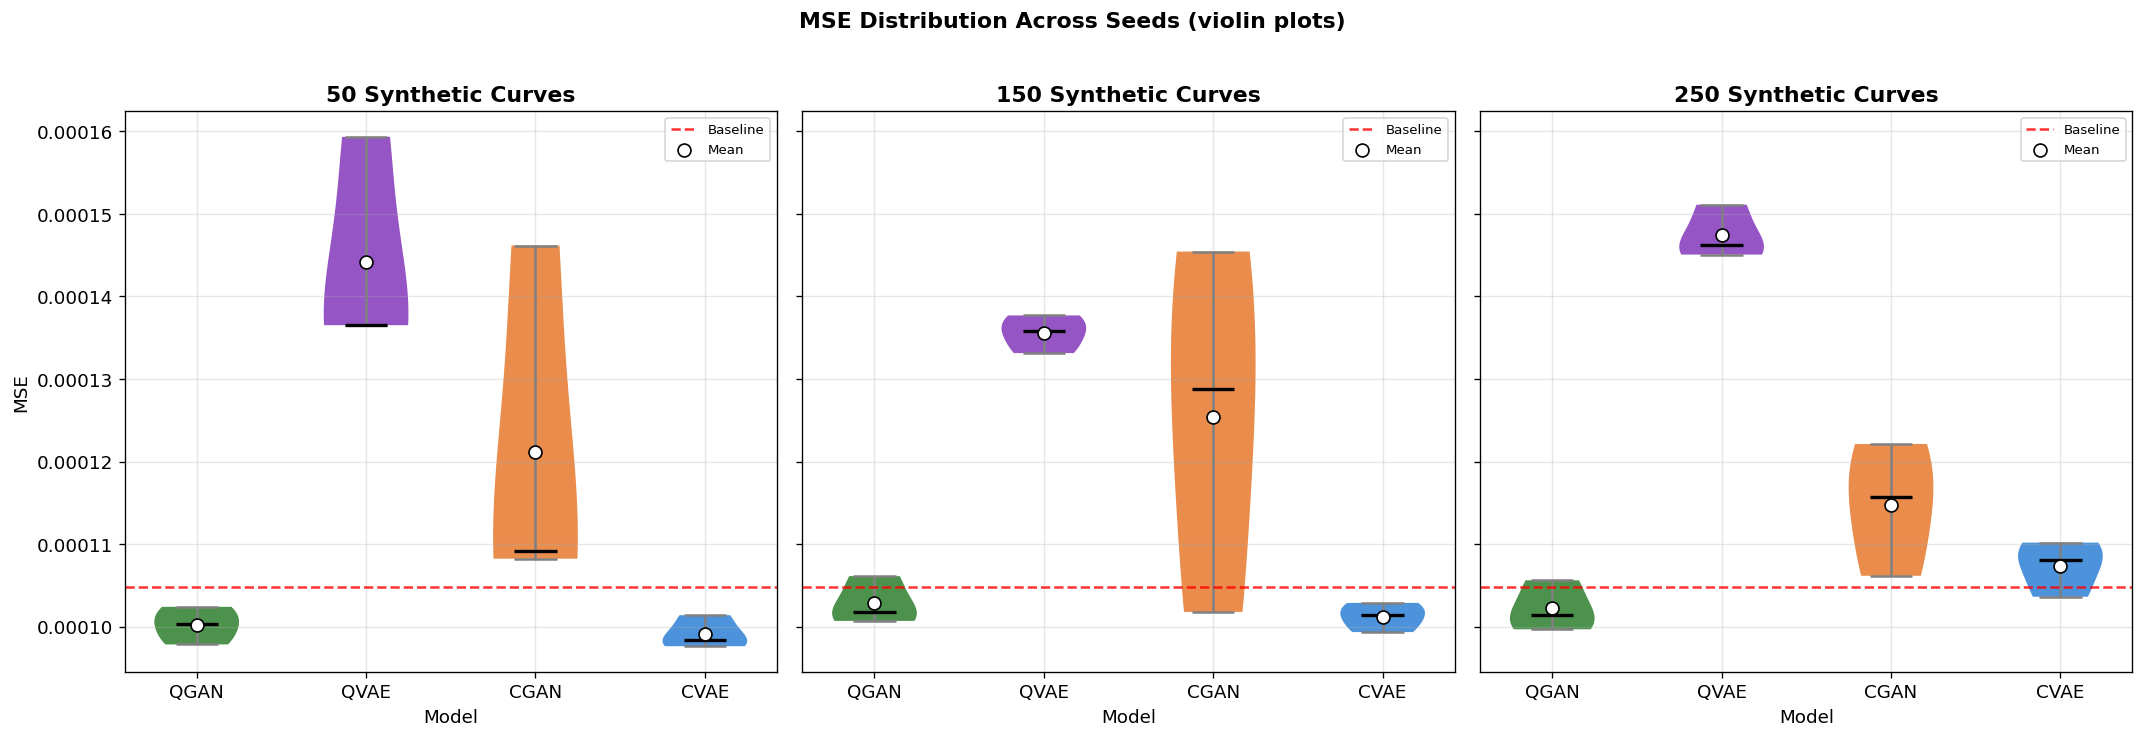

Saved: violin_mse.png


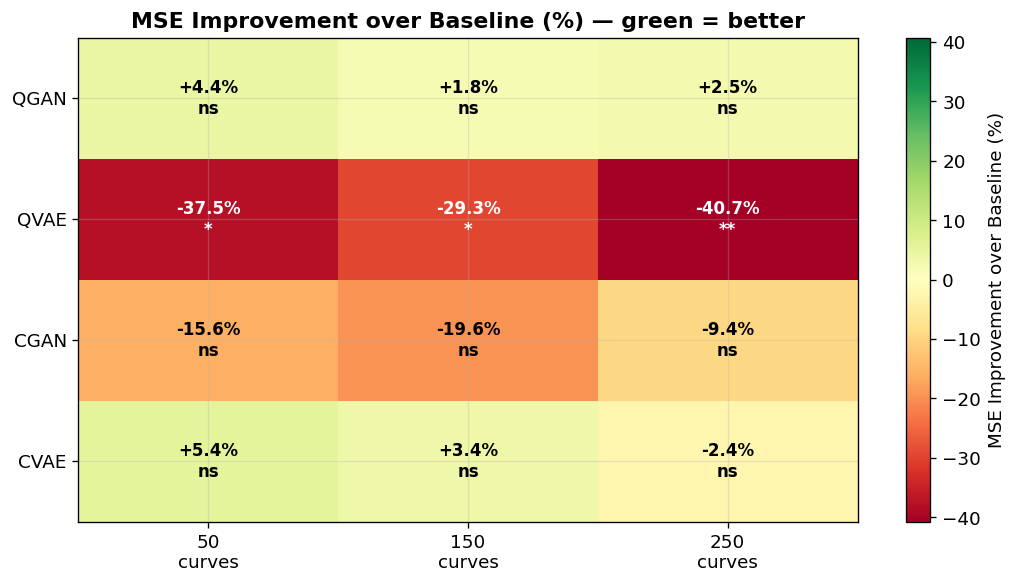

Saved: improvement_heatmap.png


In [39]:
# ── B3. VIOLIN PLOTS + IMPROVEMENT HEATMAP ───────────────────────────────────

MODEL_COLORS_B = {'QGAN': THEME_PRIMARY, 'QVAE': '#6A0DAD',
                  'CGAN': THEME_SYNTH,   'CVAE': THEME_CLS}

# ── Violin plots: MSE distribution per (model, n_synth) ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, n_synth in zip(axes, SYNTH_SIZES):
    data_by_model, colors_by_model = [], []
    labels = []
    for mn in MODELS_INFO:
        mses = [r['mse'] for r in all_results.get(mn, {}).get(n_synth, [])]
        if mses:
            data_by_model.append(mses)
            colors_by_model.append(MODEL_COLORS_B[mn.upper()])
            labels.append(mn.upper())
    if not data_by_model:
        continue
    parts = ax.violinplot(data_by_model, positions=range(len(data_by_model)),
                          showmedians=True, showextrema=True)
    for pc, color in zip(parts['bodies'], colors_by_model):
        pc.set_facecolor(color); pc.set_alpha(0.7)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    for comp in ['cmins', 'cmaxes', 'cbars']:
        parts[comp].set_color('grey')
    ax.axhline(baseline_results['mse'], color='red', linestyle='--',
               linewidth=1.5, label='Baseline', alpha=0.8)
    ax.scatter(range(len(data_by_model)),
               [np.mean(d) for d in data_by_model],
               color='white', edgecolors='black', zorder=5, s=60, label='Mean')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_title(f'{n_synth} Synthetic Curves', fontweight='bold')
    ax.set_xlabel('Model'); ax.set_ylabel('MSE' if n_synth == SYNTH_SIZES[0] else '')
    ax.legend(fontsize=8)

plt.suptitle('MSE Distribution Across Seeds (violin plots)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'violin_mse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: violin_mse.png')

# ── Improvement heatmap: (baseline_MSE - model_MSE) / baseline_MSE * 100% ────
baseline_mse = baseline_results['mse']
heat_data    = np.full((len(MODELS_INFO), len(SYNTH_SIZES)), np.nan)
row_labels   = []

for i, mn in enumerate(MODELS_INFO):
    row_labels.append(mn.upper())
    for j, n_synth in enumerate(SYNTH_SIZES):
        mses = [r['mse'] for r in all_results.get(mn, {}).get(n_synth, [])]
        if mses:
            improvement = (baseline_mse - np.mean(mses)) / baseline_mse * 100
            heat_data[i, j] = improvement

fig2, ax2 = plt.subplots(figsize=(9, 5))
vmax = max(abs(np.nanmin(heat_data)), abs(np.nanmax(heat_data)), 0.01)
im = ax2.imshow(heat_data, cmap='RdYlGn', aspect='auto',
                vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax2, label='MSE Improvement over Baseline (%)')
ax2.set_xticks(range(len(SYNTH_SIZES)))
ax2.set_xticklabels([f'{n}\ncurves' for n in SYNTH_SIZES])
ax2.set_yticks(range(len(row_labels)))
ax2.set_yticklabels(row_labels)
ax2.set_title('MSE Improvement over Baseline (%) — green = better', fontweight='bold')
for i in range(len(row_labels)):
    for j in range(len(SYNTH_SIZES)):
        val = heat_data[i, j]
        if not np.isnan(val):
            # Add significance star from DM test (averaged over seeds)
            dm_entries = dm_results.get(list(MODELS_INFO.keys())[i], {}).get(SYNTH_SIZES[j], [])
            avg_p = np.mean([e['p'] for e in dm_entries]) if dm_entries else 1.0
            star  = sig_stars(avg_p)
            ax2.text(j, i, f'{val:+.1f}%\n{star}',
                     ha='center', va='center', fontsize=10, fontweight='bold',
                     color='black' if abs(val) < vmax*0.6 else 'white')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'improvement_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: improvement_heatmap.png')

In [40]:
# ── B4. PREDICTION TRAJECTORY + RESIDUAL Q-Q ─────────────────────────────────

# Find best-performing (model, size, seed) by MSE
best_mse, best_key = float('inf'), None
for mn in MODELS_INFO:
    for n_synth in SYNTH_SIZES:
        for seed in GEN_SEEDS:
            result_path = CKPT_DIR / 'lstm_results' / \
                          f'{mn}_size{n_synth}_seed{seed}.json'
            if not result_path.exists(): continue
            with open(result_path) as f:
                res = json.load(f)
            if res['mse'] < best_mse:
                best_mse = res['mse']
                best_key = (mn, n_synth, seed)

if best_key is None:
    print('No results found. Run LSTM loop first.')
else:
    mn, n_synth, seed = best_key
    print(f'Best model: {mn.upper()}, n_synth={n_synth}, seed={seed}, MSE={best_mse:.6f}')

    pred_path = CKPT_DIR / 'lstm_results' / f'{mn}_size{n_synth}_seed{seed}.npy'
    base_path = CKPT_DIR / 'lstm_results' / 'baseline_preds.npy'

    if pred_path.exists() and base_path.exists():
        preds_best = np.load(pred_path)
        preds_base = np.load(base_path)
        y_true     = y_test_full

        fig, axes = plt.subplots(1, 2, figsize=(18, 5))

        # ── Prediction trajectory ─────────────────────────────────────────────
        ax = axes[0]
        t_idx = np.arange(len(y_true))
        ax.plot(t_idx, y_true,     color=THEME_PRIMARY, linewidth=1.5,
                label='Real growth rate', alpha=0.9, zorder=3)
        ax.plot(t_idx, preds_best, color=THEME_SYNTH, linewidth=1.2,
                linestyle='--', label=f'Best ({mn.upper()}, +{n_synth})', alpha=0.85)
        ax.plot(t_idx, preds_base, color=THEME_CLS, linewidth=1.0,
                linestyle=':', label='Baseline (real only)', alpha=0.7)
        ax.set_xlabel('Test Time Step'); ax.set_ylabel('Specific Growth Rate')
        ax.set_title('LSTM Prediction vs Ground Truth (Test Set)', fontweight='bold')
        ax.legend(fontsize=9)

        # ── Residual Q-Q plot ─────────────────────────────────────────────────
        ax2 = axes[1]
        residuals_best = preds_best - y_true
        residuals_base = preds_base - y_true

        (osm_b, osr_b), (slope_b, intercept_b, _) = stats.probplot(
            residuals_base, dist='norm')
        (osm_m, osr_m), (slope_m, intercept_m, _) = stats.probplot(
            residuals_best, dist='norm')

        ax2.scatter(osm_b, osr_b, color=THEME_CLS, s=12, alpha=0.6, label='Baseline residuals')
        ax2.plot(osm_b, slope_b * np.array(osm_b) + intercept_b,
                 color=THEME_CLS, linewidth=1.5, linestyle='--')
        ax2.scatter(osm_m, osr_m, color=THEME_SYNTH, s=12, alpha=0.6,
                    label=f'{mn.upper()} residuals')
        ax2.plot(osm_m, slope_m * np.array(osm_m) + intercept_m,
                 color=THEME_SYNTH, linewidth=1.5, linestyle='--')
        ax2.set_xlabel('Theoretical Quantiles'); ax2.set_ylabel('Sample Quantiles')
        ax2.set_title('Residual Q-Q Plot (Normal)', fontweight='bold')
        ax2.legend(fontsize=9)

        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'prediction_trajectory_residuals.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: prediction_trajectory_residuals.png')
    else:
        print('Prediction .npy files not found — set FORCE_LSTM=True and re-run.')

Best model: CVAE, n_synth=50, seed=137, MSE=0.000098
Prediction .npy files not found — set FORCE_LSTM=True and re-run.


In [41]:
# ── B5. SUMMARY TABLE WITH SIGNIFICANCE ──────────────────────────────────────

print('=' * 85)
print('FULL RESULTS SUMMARY')
print('=' * 85)
print(f'{"Model":<8} {"N_synth":>8} {"MSE mean":>12} {"MSE std":>10} '
      f'{"MAPE mean":>12} {"Improv %":>10} {"DM sig":>8} {"Cliff δ":>8}')
print('-' * 85)

# Baseline row
print(f'{"Baseline":<8} {"—":>8} {baseline_results["mse"]:>12.6f} '
      f'{"—":>10} {baseline_results["mape"]:>12.4f} {"—":>10} {"—":>8} {"—":>8}')
print('-' * 85)

for mn in MODELS_INFO:
    for n_synth in SYNTH_SIZES:
        runs = all_results.get(mn, {}).get(n_synth, [])
        if not runs: continue
        mses   = [r['mse']  for r in runs]
        mapes  = [r['mape'] for r in runs]
        improv = (baseline_results['mse'] - np.mean(mses)) / baseline_results['mse'] * 100
        # DM significance (average over seeds)
        dm_ents = dm_results.get(mn, {}).get(n_synth, [])
        dm_sig  = sig_stars(np.mean([e['p'] for e in dm_ents])) if dm_ents else '?'
        # Cliff's delta vs baseline
        cd = cliffs_delta(mses, [baseline_results['mse']] * len(mses))
        print(f'{mn.upper():<8} {n_synth:>8} {np.mean(mses):>12.6f} '
              f'{np.std(mses):>10.6f} {np.mean(mapes):>12.4f} '
              f'{improv:>+10.2f} {dm_sig:>8} {cd:>+8.3f}')

print('=' * 85)
print('Significance: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1  ns p>=0.1')
print('Cliff delta interpretation: |d|<0.15 negligible, <0.33 small, <0.47 medium, >=0.47 large')
print('Note: Wilcoxon/Kruskal-Wallis are indicative only at n=3 per condition.')
print('DM test uses full T-step error series — most reliable test here.')

FULL RESULTS SUMMARY
Model     N_synth     MSE mean    MSE std    MAPE mean   Improv %   DM sig  Cliff δ
-------------------------------------------------------------------------------------
Baseline        —     0.000105          —       1.4415          —        —        —
-------------------------------------------------------------------------------------
QGAN           50     0.000100   0.000002       2.5630      +4.40       ns   -1.000
QGAN          150     0.000103   0.000002       2.6756      +1.84       ns   -0.333
QGAN          250     0.000102   0.000002       2.5611      +2.47       ns   -0.333
QVAE           50     0.000144   0.000011       4.5925     -37.54        *   +1.000
QVAE          150     0.000136   0.000002       5.3060     -29.35        *   +1.000
QVAE          250     0.000147   0.000003       4.8259     -40.69       **   +1.000
CGAN           50     0.000121   0.000018       3.8721     -15.62       ns   +1.000
CGAN          150     0.000125   0.000018       3.3

---
# IBM Quantum Hardware Section

**This section is independently runnable.** It uses the saved synthetic checkpoints from the
simulation stage as baseline comparison, then re-runs generation on real IBM quantum hardware
and evaluates the same LSTM pipeline.

**Requirements:**
- `pip install qiskit-ibm-runtime pennylane-qiskit`
- A valid IBM Quantum account token
- All simulation checkpoints already generated (Cells 0–22 completed)

**Expected runtime:** Significant queue time depending on backend availability.
Results are saved incrementally — safe to interrupt and resume.

In [42]:
# ── IBM-0. CONFIG ─────────────────────────────────────────────────────────────
# Set your IBM token here or load from environment.
import os

IBM_TOKEN    = os.environ.get('IBM_QUANTUM_TOKEN', 'YOUR_TOKEN_HERE')
IBM_BACKEND  = 'ibm_kyiv'    # ← change to available 5-qubit backend
IBM_SHOTS    = 1024          # shots per circuit execution

# IBM experiment parameters (smaller than sim for queue time)
IBM_SYNTH_SIZES = SYNTH_SIZES     # same [50, 150, 250]
IBM_SEEDS       = GEN_SEEDS       # same 3 seeds
FORCE_IBM_GEN   = False
FORCE_IBM_LSTM  = False

print(f'IBM Backend: {IBM_BACKEND}')
print(f'Shots: {IBM_SHOTS}')
print('Note: set IBM_TOKEN env var or paste token above.')

IBM Backend: ibm_kyiv
Shots: 1024
Note: set IBM_TOKEN env var or paste token above.


In [43]:
# ── IBM-1. AUTHENTICATE & SELECT BACKEND ─────────────────────────────────────
from qiskit_ibm_runtime import QiskitRuntimeService

try:
    service = QiskitRuntimeService(
        channel='ibm_quantum',
        token=IBM_TOKEN
    )
    backend = service.backend(IBM_BACKEND)
    print(f'Connected to backend: {backend.name}')
    print(f'  Qubits:    {backend.num_qubits}')
    print(f'  Status:    {backend.status().status_msg}')
    print(f'  Queue:     {backend.status().pending_jobs} pending jobs')
    IBM_AVAILABLE = True
except Exception as e:
    print(f'IBM connection failed: {e}')
    print('IBM section will load from saved results if available.')
    IBM_AVAILABLE = False

ModuleNotFoundError: No module named 'qiskit_ibm_runtime'

In [ ]:
# ── IBM-2. IBM qGAN GENERATOR CIRCUIT ────────────────────────────────────────
# Same circuit as simulation, but using qiskit.remote backend via pennylane-qiskit.

if IBM_AVAILABLE:
    try:
        from pennylane_qiskit import IBMQDevice  # noqa: F401 — checks import

        _dev_qgan_ibm = qml.device(
            'qiskit.remote',
            wires=NUM_QUBITS,
            backend=backend,
            shots=IBM_SHOTS,
        )

        @qml.qnode(_dev_qgan_ibm, interface='torch', diff_method='parameter-shift')
        def _qgan_circuit_ibm(noise_params, par_light_params, params_pqc):
            """Identical circuit to simulation — runs on IBM hardware."""
            idx = 0
            for q in range(NUM_QUBITS):
                qml.Hadamard(wires=q)
            for q in range(NUM_QUBITS):
                qml.RZ(params_pqc[idx], wires=q); idx += 1
            for q in range(NUM_QUBITS):
                qml.RZ(noise_params[q], wires=q)
            for q in range(NUM_QUBITS):
                qml.RY(par_light_params[q] * np.pi, wires=q)
            for layer in range(NUM_LAYERS):
                for q in range(NUM_QUBITS):
                    qml.Rot(params_pqc[idx], params_pqc[idx + 1], params_pqc[idx + 2], wires=q)
                    idx += 3
                r = (layer % (NUM_QUBITS - 1)) + 1
                for q in range(NUM_QUBITS):
                    qml.CNOT(wires=[q, (q + r) % NUM_QUBITS])
            for q in range(NUM_QUBITS):
                qml.RX(params_pqc[idx], wires=q); idx += 1
                qml.RY(params_pqc[idx], wires=q); idx += 1
            return (tuple(qml.expval(qml.PauliX(q)) for q in range(NUM_QUBITS)) +
                    tuple(qml.expval(qml.PauliZ(q)) for q in range(NUM_QUBITS)))

        print('IBM qGAN circuit defined.')
        IBM_QGAN_READY = True

    except ImportError:
        print('pennylane-qiskit not installed. Run: pip install pennylane-qiskit')
        IBM_QGAN_READY = False
else:
    IBM_QGAN_READY = False
    print('IBM not available — skipping circuit definition.')

In [ ]:
# ── IBM-3. IBM qVAE SETUP ─────────────────────────────────────────────────────
# FullQuantumVAE uses PennyLane internally — swap its device to IBM backend.

if IBM_AVAILABLE and IBM_QGAN_READY:
    from qzeta.circuits import create_quantum_device

    # Build a fresh FullQuantumVAE pointed at IBM device
    _ibm_dev = qml.device(
        'qiskit.remote',
        wires=qvae_model.n_qubits if hasattr(qvae_model, 'n_qubits') else 7,
        backend=backend,
        shots=IBM_SHOTS,
    )

    try:
        n_qubits_qvae = qvae_model.n_qubits
    except AttributeError:
        n_qubits_qvae = _n_latent_qvae + 3  # 4+3=7

    qvae_ibm = FullQuantumVAE(
        input_dim    = _window_sz_qvae,
        n_latent     = _n_latent_qvae,
        n_trash      = n_qubits_qvae - _n_latent_qvae,
        n_layers     = 8,
        n_cycles     = 2,
        circuit_type = 'wang',
        backend      = 'qiskit.remote',
        diff_method  = 'parameter-shift',
        seed         = 42,
    )
    # Patch the internal device to IBM
    qvae_ibm.device = _ibm_dev
    qvae_ibm.load_state_dict(qvae_sd, strict=False)

    # Fit prior using simulation (encode-perturb method to avoid IBM queue for prior)
    print('Fitting IBM qVAE prior via simulation encode...')
    try:
        qvae_ibm.fit_prior(tensor_vae_windows, light=tensor_vae_par)
    except TypeError:
        qvae_ibm.fit_prior(tensor_vae_windows)

    print('IBM qVAE ready.')
    IBM_QVAE_READY = True
else:
    IBM_QVAE_READY = False
    print('IBM qVAE skipped.')

In [ ]:
# ── IBM-4. IBM GENERATION LOOP ────────────────────────────────────────────────
# Same structure as simulation loop; uses IBM circuits.

def _qgan_generate_one_ibm(params, par_light_norm_arr, seed=None):
    """Generate one OD curve using the IBM hardware qGAN circuit."""
    if seed is not None:
        np.random.seed(seed); torch.manual_seed(seed)

    n_windows = N_LD_POINTS // WINDOW_GAN
    with torch.no_grad():
        # FIXED (GENBUG-01): match training convention
        noise   = torch.randn(n_windows, NUM_QUBITS)
        par_mat = par_light_norm_arr[:n_windows * NUM_QUBITS].reshape(n_windows, NUM_QUBITS)
        gen_windows = []
        for i in range(n_windows):
            out = _qgan_circuit_ibm(
                noise[i],  # FIXED (GENBUG-01): row-major
                torch.tensor(par_mat[i], dtype=torch.float32),
                params
            )
            if isinstance(out, (list, tuple)):
                out = torch.stack(list(out))
            gen_windows.append(out.float())  # FIXED (GENBUG-02): removed * 0.1
        gen_windows = torch.stack(gen_windows)

    gr = denorm_qgan_output(gen_windows, MU, SIGMA, GR_MIN, GR_MAX)
    od = log_delta_to_od(gr, INITIAL_OD)
    return od, gr


IBM_MODELS = {}
if IBM_QGAN_READY:
    IBM_MODELS['ibm_qgan'] = {
        'fn':     lambda seed: _qgan_generate_one_ibm(QGAN_PARAMS, par_norm_trim, seed=seed),
        'subdir': 'ibm/synthetic/qgan',
    }
if IBM_QVAE_READY:
    IBM_MODELS['ibm_qvae'] = {
        'fn':     lambda seed: _qvae_generate_one(qvae_ibm, seed=seed),
        'subdir': 'ibm/synthetic/qvae',
    }

for model_name, info in IBM_MODELS.items():
    gen_fn   = info['fn']
    save_dir = CKPT_DIR / info['subdir']
    save_dir.mkdir(parents=True, exist_ok=True)

    for n_synth in IBM_SYNTH_SIZES:
        for seed in IBM_SEEDS:
            save_path = save_dir / f'size{n_synth}_seed{seed}.npz'
            if not FORCE_IBM_GEN and save_path.exists():
                print(f'  [{model_name}] size={n_synth} seed={seed}: exists.')
                continue

            print(f'  [{model_name}] Generating {n_synth} curves (seed={seed}) on IBM hardware...')
            od_curves, ld_curves = [], []
            for k in range(n_synth):
                try:
                    od, ld = gen_fn(seed=seed + k)
                    od_curves.append(od); ld_curves.append(ld)
                except Exception as e:
                    print(f'    Curve {k} failed: {e}')

            np.savez_compressed(save_path,
                                od_curves=np.array(od_curves, dtype=object),
                                ld_curves=np.array(ld_curves, dtype=object))
            print(f'    Saved {len(od_curves)} curves -> {save_path.name}')

if not IBM_MODELS:
    print('No IBM models available. Load results from disk if previously saved.')

In [ ]:
# ── IBM-5. IBM LSTM EVALUATION ────────────────────────────────────────────────

ibm_results = {}

ibm_model_dirs = {
    'ibm_qgan': CKPT_DIR / 'ibm/synthetic/qgan',
    'ibm_qvae': CKPT_DIR / 'ibm/synthetic/qvae',
}

for model_name, synth_dir in ibm_model_dirs.items():
    ibm_results[model_name] = {}

    for n_synth in IBM_SYNTH_SIZES:
        ibm_results[model_name][n_synth] = []

        for seed in IBM_SEEDS:
            synth_path  = synth_dir / f'size{n_synth}_seed{seed}.npz'
            result_path = CKPT_DIR / 'ibm/lstm_results' / f'{model_name}_size{n_synth}_seed{seed}.json'
            result_path.parent.mkdir(parents=True, exist_ok=True)

            if not FORCE_IBM_LSTM and result_path.exists():
                with open(result_path) as f:
                    res = json.load(f)
                ibm_results[model_name][n_synth].append(res)
                print(f'  [{model_name}] size={n_synth} seed={seed}: loaded MSE={res["mse"]:.6f}')
                continue

            if not synth_path.exists():
                print(f'  [{model_name}] {synth_path.name} not found — skipping.')
                continue

            data    = np.load(synth_path, allow_pickle=True)
            ld_list = list(data['ld_curves'])

            # Per-curve windowing (D-07, D-08): no window spans curve boundaries
            X_parts, y_parts = [], []
            # Window real training data independently
            X_r, y_r = make_lstm_dataset(real_train_ld, LOOKBACK)
            X_parts.append(X_r); y_parts.append(y_r)
            # Window each synthetic curve independently
            for ld in ld_list:
                if len(ld) > LOOKBACK:  # guard: curve must be longer than lookback
                    X_s, y_s = make_lstm_dataset(ld.astype(np.float32), LOOKBACK)
                    X_parts.append(X_s); y_parts.append(y_s)
            X_aug = np.concatenate(X_parts, axis=0)
            y_aug = np.concatenate(y_parts, axis=0)

            print(f'  [{model_name}] Training LSTM: size={n_synth} seed={seed}...')
            torch.manual_seed(seed)
            lstm_model = train_lstm(ODLSTM(), X_aug, y_aug, LSTM_EPOCHS, LSTM_LR)
            res = evaluate_lstm(lstm_model, X_test_full, y_test_full)
            res.pop('preds')

            with open(result_path, 'w') as f:
                json.dump(res, f, indent=2)
            ibm_results[model_name][n_synth].append(res)
            print(f'    MSE={res["mse"]:.6f}, MAPE={res["mape"]:.4f}')

print('IBM LSTM evaluation complete.')

In [ ]:
# ── IBM-6. SIMULATOR vs IBM HARDWARE COMPARISON ───────────────────────────────

ibm_rows = []
for model_name in ibm_model_dirs:
    for n_synth in IBM_SYNTH_SIZES:
        runs = ibm_results.get(model_name, {}).get(n_synth, [])
        if not runs:
            continue
        mses  = [r['mse']  for r in runs]
        mapes = [r['mape'] for r in runs]
        ibm_rows.append({
            'model':     model_name,
            'n_synth':   n_synth,
            'mse_mean':  np.mean(mses),
            'mse_std':   np.std(mses),
            'mape_mean': np.mean(mapes),
            'mape_std':  np.std(mapes),
        })

if ibm_rows:
    ibm_df = pd.DataFrame(ibm_rows)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    pair_map = [
        ('ibm_qgan', 'QGAN', 'IBM qGAN', THEME_PRIMARY, '#90EE90'),
        ('ibm_qvae', 'QVAE', 'IBM qVAE', '#6A0DAD', '#D8B4FE'),
    ]

    for ax, metric, ylabel in [(axes[0], 'mse', 'MSE'), (axes[1], 'mape', 'MAPE')]:
        ax.axhline(baseline_results[metric], color='black', linestyle='--',
                   linewidth=1.5, label='Baseline', zorder=5)

        for ibm_key, sim_key, label_ibm, c_sim, c_ibm in pair_map:
            # Simulator
            sim_sub = results_df[results_df['model'] == sim_key]
            if not sim_sub.empty:
                ax.errorbar(sim_sub['n_synth'], sim_sub[f'{metric}_mean'],
                            yerr=sim_sub[f'{metric}_std'],
                            fmt='-o', color=c_sim, label=f'{sim_key} (sim)',
                            capsize=3, linewidth=1.5)
            # IBM hardware
            ibm_sub = ibm_df[ibm_df['model'] == ibm_key] if ibm_rows else pd.DataFrame()
            if not ibm_sub.empty:
                ax.errorbar(ibm_sub['n_synth'], ibm_sub[f'{metric}_mean'],
                            yerr=ibm_sub[f'{metric}_std'],
                            fmt='--s', color=c_ibm, label=label_ibm,
                            capsize=3, linewidth=1.5)

        ax.set_xlabel('Synthetic Curves Added')
        ax.set_ylabel(ylabel)
        ax.set_title(f'Simulator vs IBM Hardware — {ylabel}', fontweight='bold')
        ax.legend(fontsize=9)
        ax.set_xticks(IBM_SYNTH_SIZES)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'ibm_vs_sim_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: ibm_vs_sim_comparison.png')

    # Print full IBM table
    print('\nIBM Hardware Results:')
    print(ibm_df.to_string(index=False, float_format='{:.6f}'.format))
else:
    print('No IBM results to plot. Run IBM generation and LSTM evaluation first.')